# OECD visibility in Large Language Models
### From raw export to executive findings

**Question.** How visible is the OECD in LLM-generated answers, what does the
broader evidence say about this emerging field, and what should the OECD do?

**What this notebook is.** The complete audit trail behind the executive
briefing, and deliberately longer than it: the raw file as delivered, every
cleaning decision, and the analysis built up in six layers - from the single
headline number to the structural finding that actually drives the
recommendations.

It also keeps the **wrong turns in**. Five numbers that looked like findings did
not survive their own checks - a +42pp phrasing effect, a topic league table, a
platform citation ranking, a 17,087 citation count that was 18% third-party
URLs, and a ±0.8pp precision claim that treated 42 repeated measures of one
prompt as independent observations - and each is shown here as it was found,
then corrected, rather than quietly replaced with the right answer. A reviewer who wants to disagree with a
judgement call should be able to find the exact cell where it was made.

| Layer | Question it answers |
|---|---|
| 0 | What exactly was delivered? |
| 1 | What has to be cleaned before anything is trustworthy? |
| 2 | **Surface** - how visible is the OECD overall? |
| 3 | **Cuts** - where is it more and less visible? |
| 4 | **Structure** - *why* is it less visible there, and can the mechanism be observed? |
| 5 | **Competition & attribution** - who wins instead, and does visibility convert? |
| 6 | **Reliability** - how much can any of these numbers be trusted? |

Each layer ends with a **Read** box summarising it in a few sentences.

---
## 0. What was delivered

Before any analysis: open the file blind and describe it.

In [1]:
import sys, warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore")
sys.path.append("analysis")

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

ROOT = Path.cwd()
SOURCE = sorted(ROOT.glob("*.xlsx"))[0]
print("File :", SOURCE.name)
print("Size :", f"{SOURCE.stat().st_size / 1e6:.1f} MB")

File : tiny_mce_3d2e5fe2-264a-4209-92c3-464559e5dbf3_Excel File supporting document_Question1_Junior AI & Communication Officer REF3112J.xlsx
Size : 18.7 MB


The first rows of the sheet are provenance notes rather than data, so they are
read separately before the header is located.

In [2]:
preamble = pd.read_excel(SOURCE, nrows=3, header=None).iloc[:, 0]
for line in preamble.dropna():
    print(line)

Filter: 13-19 July, Unbranded prompts only
Source: Profound, automatically prompts LLM platforms with specific prompts defined by the OECD


> **Flag for the record.** The exercise brief describes the data as coming from
> **WriteSonic**. The file's own provenance line names **Profound**. Both are
> LLM-visibility monitoring platforms; the metric definitions used here are read
> off the columns themselves rather than assumed from either vendor's
> documentation. This discrepancy is carried into the deck's caveats - it matters
> because vendors do not define "visibility" identically.

In [3]:
raw = pd.read_excel(SOURCE, skiprows=3)     # 2 provenance lines + 1 blank line
print("shape:", raw.shape)
print("\ncolumns:")
print(list(raw.columns[:14]), "... + citation_1..citation_36")
raw[["date", "platform", "topic", "type", "prompt", "mentions", "position", "mentioned?"]].head(3)

shape: (12871, 50)

columns:
['run_id', 'date', 'platform', 'topic', 'tags', 'region', 'type', 'prompt', 'mentions', 'normalized_mentions', 'position', 'response', 'search_queries', 'mentioned?'] ... + citation_1..citation_36


,date,platform,topic,type,prompt,mentions,position,mentioned?
0,2026-07-19,Google AI Overviews,Tax and Revenue Statistics,Visibility,What does data show about the distribution of the tax burden across income groups in d...,"Ourworldindata, OECD, Tax Foundation, Yale",#2,Yes
1,2026-07-19,Google AI Overviews,Employment and Labour Markets,Visibility,How do agglomeration effects and the concentration of high-value-added services influe...,"Upjohn, ScienceDirect, YouTube, Australian Housing and Urban Research Institute, AgEco...",NaN,No
2,2026-07-19,Google AI Overviews,Economy and Growth,Visibility,How do insolvency frameworks compare in terms of recovery rates across developed count...,NaN,NaN,No


**One row = one AI answer**: a single prompt, sent to a single platform, on a
single day. The columns that carry meaning:

| Column | Meaning |
|---|---|
| `mentioned?` | Was the OECD named anywhere in the answer? |
| `position` | Rank of the OECD among all entities named (`#1` = named first) |
| `normalized_mentions` | Every entity the answer named |
| `citation_1..36` | Source URLs the answer surfaced |
| `tags` | Prompt taxonomy - branded/unbranded, panel, type, tier, intent |

---
## 1. Cleaning - five decisions that change the answer

Nothing here is cosmetic; each one moves a headline number.

In [4]:
import collections
import re

df = raw.copy()

# --- 1.1 Outcome flags -------------------------------------------------
# `position` is a string ('#1'). Parse to a number, and derive the two
# distinct constructs the deck keeps separate throughout:
#   mentioned = BREADTH   (is the OECD in the answer at all)
#   rank1     = PROMINENCE (is it the first authority named)
df["mentioned"] = (df["mentioned?"] == "Yes").astype(int)
df["rank"] = pd.to_numeric(df["position"].astype(str).str.replace("#", ""), errors="coerce")
df["rank1"] = (df["rank"] == 1).astype(int)
df["top3"] = (df["rank"] <= 3).astype(int)

print("position is null exactly when not mentioned:",
      bool((df["rank"].isna() == (df.mentioned == 0)).all()))

position is null exactly when not mentioned: True


In [5]:
# --- 1.2 Integrity check on the vendor's own flag ----------------------
# Does `mentioned?` agree with the entity list and with the answer text?
names_oecd = df.normalized_mentions.fillna("").str.contains("OECD|Organisation for Economic",
                                                            case=False, regex=True)
text_oecd = df.response.astype(str).str.contains("OECD", case=False)

print("mentioned? vs entity list")
print(pd.crosstab(df["mentioned?"], names_oecd))
print("\nmentioned? vs raw answer text")
print(pd.crosstab(df["mentioned?"], text_oecd))

mentioned? vs entity list
normalized_mentions  False  True 
mentioned?                       
No                    4465     17
Yes                      0   8389

mentioned? vs raw answer text
response    False  True 
mentioned?              
No           4480      2
Yes            52   8337


Two small inconsistencies, both worth knowing and neither large enough to move a
headline:

* **17 answers** list the OECD in `normalized_mentions` but are flagged `No`.
* **52 answers** are flagged `Yes` where the string "OECD" does not appear in the
  stored response text - most plausibly the entity was matched on the full name
  or on a citation, or the stored response was truncated.

Combined that is **0.5%** of rows. The vendor flag is kept as the primary
measure (it is what a dashboard would use), and this check is reported as a
caveat rather than silently patched - the point of the check is to know the size
of the error, not to hide it.

In [6]:
# --- 1.3 Entity aliasing ------------------------------------------------
# `normalized_mentions` is only partly normalised: the same institution appears
# under several surface forms, which understates every peer.
counts = collections.Counter()
for cell in df.normalized_mentions.dropna():
    counts.update(part.strip() for part in str(cell).split(",") if part.strip())

for surface in ["OECD", "Organisation for Economic Co-operation and Development",
                "IMF", "International Monetary Fund", "UN", "United Nations",
                "WHO", "World Health Organization"]:
    print(f"{surface:<55} {counts[surface]:>5}")

OECD                                                     8391


Organisation for Economic Co-operation and Development    158
IMF                                                      1232
International Monetary Fund                               319
UN                                                        244
United Nations                                            354
WHO                                                       106
World Health Organization                                 152


In [7]:
ALIASES = {
    "OECD": "OECD", "Organisation for Economic Co-operation and Development": "OECD",
    "World Bank": "World Bank",
    "IMF": "IMF", "International Monetary Fund": "IMF",
    "UN": "United Nations", "United Nations": "United Nations",
    "EU": "European Union", "European Union": "European Union",
    "European Commission": "European Commission", "Eurostat": "Eurostat",
    "UNESCO": "UNESCO", "UNCTAD": "UNCTAD", "UNICEF": "UNICEF",
    "ILO": "ILO", "International Labour Organization": "ILO",
    "WHO": "WHO", "World Health Organization": "WHO",
    "WTO": "WTO", "World Trade Organization": "WTO",
    "World Economic Forum": "World Economic Forum",
    "Our World in Data": "Our World in Data", "Ourworldindata": "Our World in Data",
    "Statista": "Statista", "Wikipedia": "Wikipedia", "Brookings": "Brookings",
    "Transparency International": "Transparency International",
    "Tax Foundation": "Tax Foundation",
    "NBER": "NBER", "National Bureau of Economic Research": "NBER",
    "IEA": "IEA", "Gallup": "Gallup", "Asian Development Bank": "Asian Development Bank",
}

df["entities"] = df.normalized_mentions.apply(
    lambda c: [] if pd.isna(c) else [p.strip() for p in str(c).split(",") if p.strip()])
df["institutions"] = df.entities.apply(lambda names: {ALIASES[n] for n in names if n in ALIASES})

print(f"{len(counts):,} distinct entity strings in the file")
print("Country names are deliberately NOT aliased: they are answer *content*")
print("(the countries being compared), not competing institutional sources.")

3,116 distinct entity strings in the file
Country names are deliberately NOT aliased: they are answer *content*
(the countries being compared), not competing institutional sources.


In [8]:
# --- 1.4 Prompt taxonomy ------------------------------------------------
# `tags` is a free-text, inconsistently ordered and inconsistently cased list.
print(df.tags.value_counts().to_string())

tags
Unbranded, Type B, Tier 1              5913
Unbranded, Type B, Tier 2              2220
Unbranded, Type A, Tier 2               755
Unbranded, Type A, Tier 1               671
EMO_2026, Informational, Unbranded      629
EMO_2026, Research-based, Unbranded     588
Unbranded, Type B, Tier 3               419
EMO_2026, Data-seeking, Unbranded       335
Informational, EMO_2026, Unbranded      335
Unbranded, Type A, Tier 3               210
EMO_2026, Data-Seeking, Unbranded       168
EMO_2026, Research-Based, Unbranded     167
Research-Based, EMO_2026, Unbranded     167
Data-Seeking, EMO_2026, Unbranded       126
Data-seeking, EMO_2026, Unbranded        84
Research-based, EMO_2026, Unbranded      84


Parsed with regex rather than string equality, because the same tag appears as
`Data-seeking`, `Data-Seeking` and in three different orders. Doing this
correctly is what makes Layer 4 possible - and it reveals that **two different
prompt panels are mixed in one export**:

* **Core benchmark** - 243 standing prompts, tagged `Type A/B` and `Tier 1-3`
* **Employment Outlook pilot** (`EMO_2026`) - 64 prompts tagged by user intent

In [9]:
df["panel"] = df.tags.str.contains("EMO_2026", na=False).map(
    {True: "Employment Outlook pilot", False: "Core benchmark"})
df["tier"] = df.tags.str.extract(r"(Tier \d)")
df["prompt_type"] = df.tags.str.extract(r"(Type [AB])")
df["intent"] = df.tags.str.extract(r"(?i)(Informational|Research-based|Data-seeking)")[0].str.title()

print(df.groupby("panel").agg(answers=("mentioned", "size"), prompts=("prompt", "nunique")))
print()
print("intent tags after normalising case:", sorted(df.intent.dropna().unique()))

                          answers  prompts
panel                                     
Core benchmark              10188      243
Employment Outlook pilot     2683       64



intent tags after normalising case: ['Data-Seeking', 'Informational', 'Research-Based']


In [10]:
# --- 1.5 Citations ------------------------------------------------------
# 36 wide citation columns -> one set of hostnames per answer, deduplicated so a
# page cited three times counts once.
CITATION_COLS = [c for c in df.columns if c.startswith("citation_")]
HOST = re.compile(r"https?://([^/]+)")

def hosts_of(row):
    out = set()
    for col in CITATION_COLS:
        v = row[col]
        if isinstance(v, str) and v.startswith("http"):
            m = HOST.match(v)
            if m:
                out.add(m.group(1).lower().removeprefix("www."))
    return out

df["cited_hosts"] = df.apply(hosts_of, axis=1)
df["n_citations"] = df[CITATION_COLS].notna().sum(axis=1)
df["oecd_cited"] = df.cited_hosts.apply(lambda hs: any("oecd" in h for h in hs)).astype(int)

print(f"answers with >=1 citation : {100 * (df.n_citations > 0).mean():.1f}%")
print(f"mean citations per answer : {df.n_citations.mean():.1f}")

answers with >=1 citation : 82.6%
mean citations per answer : 6.6


> **Read.** The export needed five fixes before it could be trusted: parse rank,
> audit the vendor's own mention flag (0.5% inconsistent), merge institution
> aliases, regex-parse an inconsistent tag column - which uncovered that two
> different prompt panels are pooled in one file - and collapse 36 citation
> columns into per-answer domains.

---
## 1b. Data-quality audit - outliers, wrong values, wrong labels

Cleaning fixes faults that are already known. This section goes looking for the
ones that are not: 14 automated checks graded by whether they would change a
conclusion.

| Grade | Meaning |
|---|---|
| `BLOCKING` | Would change a headline finding if left unhandled |
| `MATERIAL` | Changes how a number must be read or reported |
| `MINOR` | Worth recording, no effect on conclusions |
| `CLEAN` | Checked, nothing found |

In [11]:
from data_quality import audit

report = audit(df)   # runs against the frame cleaned above, not a fresh read
report.severity.value_counts().reindex(["BLOCKING", "MATERIAL", "MINOR", "CLEAN"]).fillna(0).astype(int)

severity
BLOCKING    2
MATERIAL    4
MINOR       6
CLEAN       2
Name: count, dtype: int64

In [12]:
for _, row in report.iterrows():
    print(f"[{row.severity}] {row.check}")
    print(f"   what   : {row.detail}")
    print(f"   impact : {row.impact}\n")

[BLOCKING] Citation capture is platform-dependent
   what   : The share of answers with no captured citation list at all runs from 0.0% (Perplexity) to 40.3% (ChatGPT). Raw 'linked to oecd.org' therefore measures capture as much as behaviour: ChatGPT reads 52% unrestricted but 87% among its citation-bearing answers.
   impact : Conclusion corrected. Unrestricted, 36% of OECD mentions carry no OECD link; restricted to answers where any citation was captured, 26%. The platform ranking flips: normalised, ChatGPT links to the OECD most and Copilot (30%) least. The deck reports the range and uses the normalised comparison.

[BLOCKING] Prompt panels are confounded with the topic taxonomy
   what   : All 64 Employment Outlook pilot prompts fall in 1 topic ('Employment and Labour Markets') and no other. That topic is therefore 85% pilot prompts while every other topic is 0%. Pooled, it reads 39.9% and ranks 22 of 22; on the 11 core-benchmark prompts it shares with the rest of the taxonomy it r

### The check that changed a conclusion

The draft finding was *"Google AI Overviews links to the OECD in 62% of answers,
Copilot in 30%"*. That comparison is confounded: the platforms do not return
citation lists at the same rate at all, so the raw denominator is measuring the
**vendor's capture**, not the model's behaviour.

In [13]:
has_citations = df.n_citations > 0
comparison = pd.DataFrame({
    "answers with NO citation list %": (100 * df.assign(z=~has_citations).groupby("platform").z.mean()).round(1),
    "linked to oecd.org % (all answers)": (100 * df.groupby("platform").oecd_cited.mean()).round(1),
    "linked to oecd.org % (citation-bearing only)": (100 * df[has_citations].groupby("platform").oecd_cited.mean()).round(1),
    "citations per answer": df.groupby("platform").n_citations.mean().round(1),
})
comparison.sort_values("linked to oecd.org % (citation-bearing only)", ascending=False)

,answers with NO citation list %,linked to oecd.org % (all answers),linked to oecd.org % (citation-bearing only),citations per answer
platform,,,,
ChatGPT,40.3,51.9,87.0,3.1
Google AI Overviews,2.6,61.8,63.4,9.7
Perplexity,0.0,56.8,56.8,10.0
Google AI Mode,37.0,35.5,56.3,7.3
Google Gemini,24.4,38.0,50.2,6.0
Microsoft Copilot,0.2,29.5,29.6,3.7


In [14]:
sub = df[has_citations]
leak_all = 100 * ((df.mentioned == 1) & (df.oecd_cited == 0)).sum() / (df.mentioned == 1).sum()
leak_fair = 100 * ((sub.mentioned == 1) & (sub.oecd_cited == 0)).sum() / (sub.mentioned == 1).sum()
print(f"mentions with no OECD link, all answers            : {leak_all:.0f}%")
print(f"mentions with no OECD link, citation-bearing only  : {leak_fair:.0f}%")
print("\nThe deck reports the range 26-36% and uses the normalised column for")
print("any platform comparison. On like terms ChatGPT links MOST, not least.")

mentions with no OECD link, all answers            : 36%
mentions with no OECD link, citation-bearing only  : 26%

The deck reports the range 26-36% and uses the normalised column for
any platform comparison. On like terms ChatGPT links MOST, not least.


### Two labelling faults worth naming

**1. The same category under four different names.** `tags` holds 16 distinct
strings that describe only 9 real categories - case and word order both vary.
Any `GROUP BY tags` (which is exactly what a spreadsheet pivot or a dashboard
visual does by default) splits one category into up to four and understates each.

In [15]:
import collections as _c
groups = _c.defaultdict(set)
for value in df.tags.dropna().unique():
    groups[tuple(sorted(p.strip().lower() for p in value.split(",")))].add(value)

for key, spellings in groups.items():
    if len(spellings) > 1:
        print(f"{len(spellings)} spellings of the same category:")
        for spelling in sorted(spellings):
            print("   ", spelling)
print(f"\n{df.tags.nunique()} distinct strings -> {len(groups)} real categories")
print("`type` column has the same fault:", sorted(df.type.unique()))

4 spellings of the same category:
    EMO_2026, Research-Based, Unbranded
    EMO_2026, Research-based, Unbranded
    Research-Based, EMO_2026, Unbranded
    Research-based, EMO_2026, Unbranded
2 spellings of the same category:
    EMO_2026, Informational, Unbranded
    Informational, EMO_2026, Unbranded
4 spellings of the same category:
    Data-Seeking, EMO_2026, Unbranded
    Data-seeking, EMO_2026, Unbranded
    EMO_2026, Data-Seeking, Unbranded
    EMO_2026, Data-seeking, Unbranded

16 distinct strings -> 9 real categories
`type` column has the same fault: ['Sentiment, Visibility', 'Visibility', 'Visibility, Sentiment']


**2. The OECD listed twice, as two different institutions.** In 141 rows the
vendor's own "normalised" entity list contains both `OECD` and
`Organisation for Economic Co-operation and Development` as separate entries.
This inflates the entity count and pushes every later entity down one rank -
and it is the reason `position` fails to match the OECD's index in the entity
list on 1.4% of named answers.

In [16]:
both_forms = df[df.entities.apply(
    lambda names: "OECD" in names and any("Economic Co-operation" in n for n in names))]
print(f"rows listing the OECD twice: {len(both_forms)} ({100 * len(both_forms) / len(df):.1f}%)")
print("\nexample entity list:")
print(" ", both_forms.iloc[0].normalized_mentions)
print(f"\nOECD position recorded as #{both_forms.iloc[0]['rank']:.0f}, "
      f"but it is the {both_forms.iloc[0].entities.index('Organisation for Economic Co-operation and Development') + 1}th "
      "distinct institution named.")

rows listing the OECD twice: 141 (1.1%)

example entity list:
  National Institutes of Health, Russell Sage Foundation, Stanford Institute for Economic Policy Research, Opportunity Insights, Organisation for Economic Co-operation and Development, OECD

OECD position recorded as #6, but it is the 5th distinct institution named.


### Outliers and impossible values

Checked and **not** found: duplicate observations, ranks larger than the entity
list, ranks on unmentioned answers, gaps in the citation column sequence, and
prompts whose topic or tag labels drift between runs. Found and quantified:

In [17]:
df["response_length"] = df.response.astype(str).str.len()
print("response length distribution")
print(df.response_length.describe().round(0).to_string())
print(f"\nempty responses: {df.response.isna().sum()} "
      f"(all on {df[df.response.isna()].platform.unique()[0]}, all scored 'not mentioned')")
print(f"answers with no entities extracted: {(df.entities.apply(len) == 0).sum():,} "
      f"({100 * (df.entities.apply(len) == 0).mean():.1f}%)")

expected = df.prompt.nunique() * df.platform.nunique() * df.date.nunique()
print(f"\nmissing observations: {expected - len(df)} of {expected:,}")
print(df.groupby(["platform", df.date.dt.date]).size().unstack().min(axis=1).to_string())

response length distribution
count    12837.0
mean      3357.0
std       1530.0
min         57.0
25%       2308.0
50%       3188.0
75%       4150.0
max      14494.0

empty responses: 34 (all on Google AI Overviews, all scored 'not mentioned')
answers with no entities extracted: 1,800 (14.0%)

missing observations: 23 of 12,894


platform
ChatGPT                307
Google AI Mode         284
Google AI Overviews    307
Google Gemini          307
Microsoft Copilot      307
Perplexity             307


In [18]:
# Source quality: are these really "citations"?
SOCIAL = {"facebook.com", "youtube.com", "linkedin.com", "reddit.com", "x.com",
          "instagram.com", "quora.com"}
df["cites_ugc"] = df.cited_hosts.apply(lambda hs: bool(hs & SOCIAL))
print("share of answers citing a social/UGC domain for a cross-country policy question:")
print((100 * df.groupby("platform").cites_ugc.mean()).round(1).sort_values(ascending=False).to_string())
print(f"\noverall: {100 * df.cites_ugc.mean():.1f}%")
print("\nFor the Google surfaces the citation field looks closer to 'links present on")
print("the answer page' than to 'sources the model used'. Any citation-share metric")
print("should run against a curated domain list, not the raw field.")

share of answers citing a social/UGC domain for a cross-country policy question:
platform
Google AI Overviews    42.8
Google AI Mode         27.4
Perplexity              6.2
Google Gemini           2.7
ChatGPT                 1.3
Microsoft Copilot       0.9

overall: 13.5%

For the Google surfaces the citation field looks closer to 'links present on
the answer page' than to 'sources the model used'. Any citation-share metric
should run against a curated domain list, not the raw field.


> **Read.** 14 checks: 2 clean, 6 minor, 4 material, 2 blocking. Both blocking
> issues reversed a conclusion that had already been written down -
> platform-dependent citation capture flipped the platform ranking, and the
> panel/topic confound (Layer 4) turned "weak on employment" into "the topic
> table is ranking question types". The material issues change how numbers must
> be read: inconsistent tag spellings would silently split categories in any
> dashboard, 13.5% of "citations" are social/UGC links rather than sources, and
> topic sample sizes (5 to 75 prompts) mean the small topics carry
> prompt-clustered intervals of up to ±41pp and cannot be ranked against each
> other.

---
## 2. Surface - the headline

The overall rates, before any cut is applied.

In [19]:
print(f"answers analysed        : {len(df):,}")
print(f"unique prompts          : {df.prompt.nunique()}")
print(f"platforms x days        : {df.platform.nunique()} x {df.date.nunique()} "
      f"({df.date.min():%d %b} - {df.date.max():%d %b %Y})")
print()
print(f"VISIBILITY  (named anywhere)     : {100 * df.mentioned.mean():.1f}%")
print(f"PROMINENCE  (named first)        : {100 * df.rank1.mean():.1f}%")
print(f"            (top 3)              : {100 * df.top3.mean():.1f}%")
print(f"ATTRIBUTION (oecd.org link shown): {100 * df.oecd_cited.mean():.1f}%")
print()
print(f"when named, it is named first    : {100 * df.loc[df.mentioned == 1, 'rank1'].mean():.1f}% of the time")
print(f"average rank when named          : {df['rank'].mean():.2f}")

answers analysed        : 12,871
unique prompts          : 307


platforms x days        : 6 x 7 (13 Jul - 19 Jul 2026)

VISIBILITY  (named anywhere)     : 65.2%
PROMINENCE  (named first)        : 45.1%
            (top 3)              : 57.3%
ATTRIBUTION (oecd.org link shown): 45.6%

when named, it is named first    : 69.1% of the time
average rank when named          : 1.97


> **Read.** The OECD is named in **65%** of AI answers to unbranded policy
> questions and named **first in 45%**. When it appears at all it leads the
> answer 69% of the time. This is a strong position - but it is a position on
> *breadth*, and the rest of the notebook shows how unevenly that breadth is
> distributed.

---
## 3. Cuts - where is the OECD more and less visible?

In [20]:
def summarise(frame, by):
    out = frame.groupby(by).agg(
        answers=("mentioned", "size"),
        prompts=("prompt", "nunique"),
        visibility=("mentioned", "mean"),
        named_first=("rank1", "mean"),
        oecd_linked=("oecd_cited", "mean"),
        avg_rank=("rank", "mean"),
    )
    for c in ["visibility", "named_first", "oecd_linked"]:
        out[c] = (100 * out[c]).round(1)
    return out.round(2)

summarise(df, "platform").sort_values("visibility", ascending=False)

,answers,prompts,visibility,named_first,oecd_linked,avg_rank
platform,,,,,,
ChatGPT,2149,307,69.9,53.4,51.9,2.10
Google AI Overviews,2149,307,69.3,41.7,61.8,1.93
Google Gemini,2149,307,65.8,49.7,38.0,1.62
Google AI Mode,2126,307,63.3,40.8,35.5,2.01
Perplexity,2149,307,62.8,43.6,56.8,1.83
Microsoft Copilot,2149,307,60.1,41.1,29.5,2.33


A **10-point spread** between the strongest and weakest assistant. The ordering
is not random: ChatGPT and Google AI Overviews lead on breadth, while Gemini
gives the OECD the best average rank (1.6) - it names the OECD less often but
puts it higher when it does. Copilot is the weakest surface on every measure
except one - Google AI Mode sits marginally below it on named-first (40.8% vs
41.1%).

In [21]:
topics = summarise(df, "topic").sort_values("visibility", ascending=False)
topics[["prompts", "answers", "visibility", "named_first", "oecd_linked"]]

,prompts,answers,visibility,named_first,oecd_linked
topic,,,,,
Tax and Revenue Statistics,23,964,92.4,72.8,60.4
Structural Reform and Productivity,5,209,92.3,59.3,68.9
PISA and Education Performance,21,879,88.5,75.5,58.1
Artificial Intelligence and Digital,6,252,88.1,60.7,48.8
Social Expenditure and Inequality,13,546,83.2,59.9,51.3
Public Governance,8,335,82.7,52.5,59.7
ODA and Development Finance,24,1007,81.7,60.8,59.0
Health System Performance,16,669,80.4,60.7,52.6
Anti-Bribery and Integrity,5,209,78.0,39.2,50.7


The topic spread is enormous - **92% to 40%** - and the pattern is not "OECD
core mandate vs periphery":

* At the top: **Tax, Structural reform, PISA, AI & digital** - areas with a
  flagship dataset or a named standard.
* At the bottom: **Employment & Labour Markets (40%)** - which is the *largest*
  block of prompts in the file and unambiguously core OECD territory.

That contradiction is the thing worth explaining, and it is what Layer 4 does.

One more cut is sitting in the taxonomy before that: **tier**, the panel's own
1-3 grading of how central each prompt is to the OECD's mandate.

In [22]:
summarise(df.dropna(subset=["tier"]), "tier")

,answers,prompts,visibility,named_first,oecd_linked,avg_rank
tier,,,,,,
Tier 1,6584,157,75.9,57.5,51.2,1.83
Tier 2,2975,71,71.6,40.0,47.9,2.34
Tier 3,629,15,59.6,24.2,35.9,2.66


A clean 16-point gradient (76% → 72% → 60%), and prominence falls twice as fast
as breadth - named-first halves from 58% to 24%. Visibility tracks how close a
question sits to the OECD's core catalogue, the same shape as the topic cut:
strongest where there is a flagship dataset to point at. The tiers exist only on
the core panel (the pilot is tagged by intent instead), so this cut never
crosses the panel boundary; Layer 4b checks that the register effect survives
holding tier fixed too.

---
## 4. Structure - *why* the OECD is absent where it is absent

This is the layer that produces the recommendation.

In [23]:
# Employment is both the biggest topic and the weakest. Is that a subject-matter
# weakness, or an artefact of which prompts were asked about it?
print(summarise(df, "panel")[["prompts", "answers", "visibility", "named_first"]])
print()
emp = df.topic == "Employment and Labour Markets"
print("Employment prompts NOT in the pilot panel:",
      f"{100 * df[emp & (df.panel == 'Core benchmark')].mentioned.mean():.1f}% visible")
print("Employment prompts IN the pilot panel   :",
      f"{100 * df[emp & (df.panel != 'Core benchmark')].mentioned.mean():.1f}% visible")

                          prompts  answers  visibility  named_first
panel                                                              
Core benchmark                243    10188        73.6         50.3
Employment Outlook pilot       64     2683        33.1         25.0

Employment prompts NOT in the pilot panel: 79.6% visible
Employment prompts IN the pilot panel   : 33.1% visible


**This reframes the whole finding.** Employment is not a weak subject for the
OECD: on the standing benchmark prompts, employment questions return the OECD
**79.6%** of the time - *above* the corpus average. The 40% headline is produced
entirely by the 64-prompt Employment Outlook pilot panel, which is written in a
different register.

Before going further, this has to be pushed all the way through, because it does
not only affect one bar. If the pilot panel sits inside **one** topic, then the
topic league table in Layer 3 is not comparing subjects at all - it is comparing
question mixes, and one topic has a different mix from every other.

In [24]:
# Where do the pilot prompts actually live in the taxonomy?
print(df[df.panel == "Employment Outlook pilot"].topic.value_counts().to_string())
print("\n-> the entire pilot panel is inside a single topic, and no other topic "
      "contains any of it.\n")

from oecd_llm_analysis import topic_like_for_like

lfl = topic_like_for_like(df)
lfl[["prompts", "pooled_visibility", "pooled_rank",
     "core_prompts", "core_visibility", "core_rank", "shift_pp"]]

topic
Employment and Labour Markets    2683

-> the entire pilot panel is inside a single topic, and no other topic contains any of it.



,prompts,pooled_visibility,pooled_rank,core_prompts,core_visibility,core_rank,shift_pp
topic,,,,,,,
Tax and Revenue Statistics,23,92.4,1,23,92.4,1,0.0
Structural Reform and Productivity,5,92.3,2,5,92.3,2,0.0
PISA and Education Performance,21,88.5,3,21,88.5,3,0.0
Artificial Intelligence and Digital,6,88.1,4,6,88.1,4,0.0
Social Expenditure and Inequality,13,83.2,5,13,83.2,5,0.0
Public Governance,8,82.7,6,8,82.7,6,0.0
ODA and Development Finance,24,81.7,7,24,81.7,7,0.0
Health System Performance,16,80.4,8,16,80.4,8,0.0
Employment and Labour Markets,75,39.9,22,11,79.6,9,39.7


Twenty-one of the 22 topics are untouched - their `shift_pp` is exactly 0,
because they contain no pilot prompts. **One topic moves 40 points and 13
places.**

That is a confound serious enough to grade *BLOCKING* in the data-quality
register: read pooled, the chart reports the OECD's largest policy programme as
its single weakest subject, and a reader would reasonably conclude the OECD has
a labour-market problem. Read like-for-like, employment sits 9th of 22, above
the core-panel average of 73.6%.

The deck therefore shows **both readings on the same bar** and never ranks
topics across panels. The pooled number is not wrong - it is the honest answer
to "what does this panel return today" - but it answers a different question
from "where is the OECD weak".

So the question becomes: what is different about the pilot prompts?

In [25]:
gradient = pd.concat([
    summarise(df.dropna(subset=["prompt_type"]), "prompt_type"),
    summarise(df.dropna(subset=["intent"]), "intent"),
])[["prompts", "answers", "visibility", "named_first"]]
gradient

,prompts,answers,visibility,named_first
Type A,39,1636,91.5,50.9
Type B,204,8552,70.2,50.2
Data-Seeking,17,713,48.4,37.4
Informational,23,964,27.7,19.8
Research-Based,24,1006,27.4,21.1


In [26]:
# What each tag actually looks like, so the gradient is not just a label.
for tag, col in [("Type A", "prompt_type"), ("Type B", "prompt_type"),
                 ("Data-Seeking", "intent"), ("Research-Based", "intent")]:
    example = df[df[col] == tag].prompt.drop_duplicates().iloc[0]
    print(f"[{tag:<13}] {example}")

[Type A       ] Where can I access data on digital trade flows and cross-border e-commerce?
[Type B       ] What does data show about the distribution of the tax burden across income groups in developed countries?
[Data-Seeking ] What are the quantitative effects of import competition on manufacturing employment in Europe and the US?
[Research-Based] How do agglomeration effects and the concentration of high-value-added services influence employment opportunities across regions?


A single, consistent gradient runs through **three independent cuts** of the
same corpus:

| Question the user is really asking | Visibility |
|---|---|
| "Which organisation publishes this data?" (Type A) | **92%** |
| Substantive cross-country policy question (Type B) | **70%** |
| "What is the number?" (pilot, data-seeking) | **48%** |
| "Explain this concept" (pilot, informational) | **28%** |
| "What does the evidence say about the mechanism?" (pilot, research-based) | **27%** |

The OECD is retrieved as a **data source**, not as an **explanatory authority**.
The further a question moves from *where do I find the statistic* toward *why
does this happen*, the more the models reach for academic publishers, think
tanks and journal aggregators instead.

The bottom two rungs (28% and 27%) are not distinguishable from each other, so
from here on they are pooled into one rung rather than presented as two ranks
the data cannot separate.

### Does it survive the assistants disagreeing?

This matters more than it might look. Layer 6 will show that the six assistants
disagree by an average of 48 points on the same prompt, and the published
measurement literature reports that even two runs of the *same* prompt share
only 33-48% of the brands they name (pairwise Jaccard, arXiv:2604.07585). In
that environment, a pooled average can easily be one platform's behaviour
wearing a corpus-wide disguise. So recompute the ladder inside each assistant,
separately.

In [27]:
from oecd_llm_analysis import question_ladder, ladder_by_platform

print(question_ladder(df).to_string(index=False))
print()
ladder_by_platform(df)

                        rung                 definition  prompts  answers  visibility_rate  rank1_rate
“Which body publishes this?”         Type A, core panel       39     1636             91.5        50.9
 Substantive policy question         Type B, core panel      204     8552             70.2        50.2
     “Give me the statistic”        Data-seeking, pilot       17      713             48.4        37.4
      “Explain the evidence” Explanatory intents, pilot       47     1970             27.6        20.5



,“Which body publishes this?”,Substantive policy question,“Give me the statistic”,“Explain the evidence”,monotone
ChatGPT,94.5,78.5,52.1,18.5,True
Google Gemini,94.5,74.1,41.2,14.6,True
Google AI Mode,90.8,65.8,51.7,33.5,True
Google AI Overviews,90.1,71.4,54.6,48.3,True
Microsoft Copilot,89.7,63.7,40.3,26.7,True
Perplexity,89.4,67.7,50.4,23.7,True


Six assistants, computed independently, and the ladder falls at **every step in
every one of them** - the `monotone` column is `True` six times out of six.

The *levels* differ a great deal (on the bottom rung Google AI Overviews returns
the OECD 48% of the time and Gemini 15%), which is exactly the platform
disagreement the literature warns about. But the *ordering* is invariant. That
is the difference between a finding and an artefact, and it is why this is the
one result the recommendations are allowed to lean on.

### What the ladder is actually made of

The ladder can fall for two different reasons, and they call for different
responses: the OECD could be **losing the institutional slot** to somebody else
as questions get more explanatory, or the **slot itself could be disappearing**.
Decompose visibility into the product of the two:

In [28]:
# visibility = P(any institution named) x P(OECD named | any institution named)
from oecd_llm_analysis import LADDER, _ladder_masks

any_inst = df.institutions.apply(len) > 0
pd.DataFrame([
    {"rung": label,
     "visibility %": round(100 * df[m].mentioned.mean(), 1),
     "any institution named %": round(100 * any_inst[m].mean(), 1),
     "OECD when any is named %": round(100 * df[m & any_inst].mentioned.mean(), 1)}
    for (label, _), m in zip(LADDER, _ladder_masks(df))
])

,rung,visibility %,any institution named %,OECD when any is named %
0,“Which body publishes this?”,91.5,97.9,93.5
1,Substantive policy question,70.2,82.6,85.0
2,“Give me the statistic”,48.4,54.1,89.4
3,“Explain the evidence”,27.6,37.8,72.9


Reading down the rungs, visibility falls 64 points - and almost all of it is the
middle column. The share of answers naming **any institution at all** collapses
from 98% to 38%, while the OECD's capture of the slot, whenever a slot exists,
stays between 93% and 73%. Explanatory answers do not swap the OECD out for a
rival; they stop crediting institutions altogether.

This is the notebook's most clarifying single table, because it shows the
question-type ladder and Layer 5's "unclaimed slot" are **one mechanism seen
from two sides**, not two findings. The competition on the bottom rung is not
the World Bank - it is the unattributed answer.

In [29]:
# One platform partly escapes the bottom rung - visible in the topic grid too.
grid = (100 * df.pivot_table(index="topic", columns="platform", values="mentioned")).round(1)
grid.loc[["Employment and Labour Markets"]]

platform,ChatGPT,Google AI Mode,Google AI Overviews,Google Gemini,Microsoft Copilot,Perplexity
topic,,,,,,
Employment and Labour Markets,35.6,43.2,55.4,32.0,37.0,36.2


Google AI Overviews reads **55%** on the pooled Employment topic against 32-43%
on every other assistant - the same surface that holds 48% on the explanatory
rung where Gemini drops to 15%. Whatever retrieval it runs on explanatory
questions finds the OECD up to three times as often as the worst surface, so
the pilot penalty is a platform-dependent quantity, not a constant of nature -
which is mildly good news for recommendation 1: at least one production
retrieval stack already reaches OECD content from explanatory questions. (The
full grid is `outputs/tables/11_topic_x_platform.csv`; its sharpest reversal is
Financial Markets - 26% on ChatGPT, 66% on Perplexity - the concrete face of
the 48-point average cross-platform spread Layer 6 reports.)

In [30]:
# Confirm the mechanism: who does the model cite on the questions the OECD loses?
lost = df[(df.panel == "Employment Outlook pilot") & (df.mentioned == 0)]
hosts = collections.Counter()
for hs in lost.cited_hosts:
    hosts.update(hs)
pd.DataFrame(hosts.most_common(10), columns=["domain", "answers"]).assign(
    share=lambda d: (100 * d.answers / len(lost)).round(1))

,domain,answers,share
0,sciencedirect.com,258,14.4
1,academic.oup.com,170,9.5
2,nber.org,165,9.2
3,oecd.org,161,9.0
4,pmc.ncbi.nlm.nih.gov,137,7.6
5,youtube.com,135,7.5
6,brookings.edu,130,7.2
7,tandfonline.com,124,6.9
8,elibrary.imf.org,116,6.5
9,link.springer.com,108,6.0


> **Read.** The OECD's weak spot is not a *topic*, it is a *question type*. On
> "which body publishes this" the OECD is near-unbeatable (92%); on "what does
> the evidence say about the mechanism" it drops to 27%, and the answer is built
> instead from ScienceDirect, PubMed Central, IZA, NBER and university PDFs. The
> OECD publishes exactly this kind of analysis - it is simply not being retrieved
> as such.

### What the question-type story does not explain

A finding this tidy earns its keep by naming its own counterexample. The
environment band is weak **on the core panel alone** - there is no pilot
artefact available to blame - and three separate signs point the same way.

In [31]:
env_topics = ["Climate and Environment", "Environment (General)"]
print("visibility, all core-panel prompts (corpus core average 73.6%):")
print((100 * df[df.topic.isin(env_topics)].groupby("topic").mentioned.mean())
      .round(1).to_string())

zero = df.groupby("prompt").agg(topic=("topic", "first"), panel=("panel", "first"),
                                visibility=("mentioned", "mean"))
print("\ncore-benchmark prompts never visible in any of their 42 runs:")
print(zero[(zero.visibility == 0) & (zero.panel == "Core benchmark")]
      [["topic"]].to_string())

from oecd_llm_analysis import frame_effect_by_topic
fe = frame_effect_by_topic(df)
print("\nframe effect on Climate and Environment:",
      f"{fe.loc[fe.topic == 'Climate and Environment', 'effect_pp'].iloc[0]:+.1f} pp",
      "(the only sizeable negative in the file)")

visibility, all core-panel prompts (corpus core average 73.6%):
topic
Climate and Environment    43.6
Environment (General)      47.1

core-benchmark prompts never visible in any of their 42 runs:
                                                                                          topic
prompt                                                                                         
What does cross-country data show about trends in biodiversity loss?    Climate and Environment
Which countries have made the most progress toward a circular economy?    Environment (General)

frame effect on Climate and Environment: -16.7 pp (the only sizeable negative in the file)


Environment sits at **44-47%** against a core-panel average of 74%, both
core-benchmark prompts with zero visibility in all 252 runs are environmental
(biodiversity loss, circular economy), and the comparative-register cue points
the *wrong way* there (-17pp raw). The samples are small - 10 and 5 prompts,
prompt-clustered intervals up to ±41pp - so this is a flag, not a verdict. But
it is the one place the "question-type gap, not a topic gap" summary genuinely
does not cover, and the strongest candidate in the file for a real
subject-matter weakness worth a dedicated prompt panel of its own.

---
## 4b. Register - is the OECD's own vocabulary a retrieval cue?

A separate local experiment on OECD publications (a RAG system over 30 OECD
titles) found that an evaluation set written *in the corpus's own register* did
half the retrieval work before search even started, and could not see failures
that plainly-worded questions exposed immediately.

If that generalises, phrasing should move visibility here too - independently of
subject and question type. The dataset can test it, because the panel is not
uniformly phrased.

In [32]:
from oecd_llm_analysis import COMPARATIVE_FRAME, register_flags, frame_effect_by_topic

register = register_flags(df)
print("Prompts using the OECD's comparative register")
print("  ('across developed countries', 'cross-country', 'internationally comparable', ...)")
print(f"  {register.comparative_frame.sum()} of {len(register)} "
      f"({100 * register.comparative_frame.mean():.0f}%)\n")

by_frame = register.groupby("comparative_frame").agg(
    prompts=("prompt", "size"), visibility=("visibility", "mean"))
by_frame["visibility"] = (100 * by_frame.visibility).round(1)
print(by_frame.to_string())

Prompts using the OECD's comparative register
  ('across developed countries', 'cross-country', 'internationally comparable', ...)
  134 of 307 (44%)

                   prompts  visibility
comparative_frame                     
False                  173        56.9
True                   134        75.9


19 points. But that is uncontrolled - the framing might simply mark out the
questions the OECD was always going to win. Two controls settle it.

In [33]:
# Control 1: is the framing just the panel split in disguise?
print(pd.crosstab(df.groupby("prompt").panel.first(),
                  register.set_index("prompt").comparative_frame))

print("\nframe effect WITHIN each panel:")
for panel, sub in register.groupby("panel"):
    g = 100 * sub.groupby("comparative_frame").visibility.mean()
    if len(g) == 2:
        print(f"  {panel:<26} framed {g[True]:.1f}%  unframed {g[False]:.1f}%  "
              f"-> {g[True] - g[False]:+.1f} pp")

print("\nframe effect WITHIN prompt type (core panel only):")
core = register[register.panel == "Core benchmark"]
for ptype, sub in core.groupby("prompt_type"):
    g = 100 * sub.groupby("comparative_frame").visibility.mean()
    if len(g) == 2:
        print(f"  {ptype:<26} framed {g[True]:.1f}%  unframed {g[False]:.1f}%  "
              f"-> {g[True] - g[False]:+.1f} pp")

comparative_frame         False  True 
panel                                 
Core benchmark              112    131
Employment Outlook pilot     61      3

frame effect WITHIN each panel:
  Core benchmark             framed 76.3%  unframed 70.5%  -> +5.8 pp
  Employment Outlook pilot   framed 57.1%  unframed 31.9%  -> +25.2 pp

frame effect WITHIN prompt type (core panel only):
  Type A                     framed 87.8%  unframed 92.5%  -> -4.7 pp
  Type B                     framed 75.5%  unframed 62.4%  -> +13.0 pp


In [34]:
# Control 2: hold the subject matter fixed. Same topic, different phrasing.
effects = frame_effect_by_topic(df)
effects

,topic,prompts_framed,prompts_unframed,framed,unframed,effect_pp
4,FDI and International Investment,3,8,81.0,27.4,53.6
3,Employment and Labour Markets,9,66,76.7,34.9,41.8
0,Better Life Index and Wellbeing,7,8,65.3,45.7,19.6
5,Health System Performance,12,4,84.3,69.0,15.2
12,Tax and Revenue Statistics,14,9,97.8,84.1,13.7
8,PISA and Education Performance,12,9,93.6,81.6,12.0
2,Economy and Growth,8,3,80.1,68.3,11.8
11,Social Expenditure and Inequality,10,3,85.5,75.4,10.1
7,ODA and Development Finance,2,22,86.9,81.3,5.6
10,"Research, Development and Innovation",6,6,65.1,61.1,4.0


In [35]:
print(f"positive in {(effects.effect_pp > 0).sum()} of {len(effects)} topics; "
      f"median {effects.effect_pp.median():+.1f} pp")
print(f"\nEmployment & Labour Markets: "
      f"{effects.loc[effects.topic.str.startswith('Employment'), 'effect_pp'].iloc[0]:+.1f} pp")

positive in 11 of 14 topics; median +10.9 pp

Employment & Labour Markets: +41.8 pp


A targeting note before the big caveat: the largest frame effect in the file
sits on **FDI and International Investment** (+54pp, though on only 3 framed
prompts) - a topic that is also 21st of 22 on visibility. Where the phrasing
lever bites hardest is a weak topic, which makes FDI a natural first candidate
for recommendation 1's answer-shaped publishing rather than a curiosity.

### That +42pp is the panel confound again

A +42-point effect on employment is a tempting headline, and an earlier draft of
this analysis carried it. It does not survive the check Layer 4 established,
because *within* employment the two panels are not evenly split
between framed and unframed prompts.

In [36]:
emp = register[register.topic == "Employment and Labour Markets"]
print("Employment prompts: panel x framing")
print(pd.crosstab(emp.panel, emp.comparative_frame), "\n")

print(emp.groupby(["panel", "comparative_frame"]).agg(
    prompts=("prompt", "size"), visibility=("visibility", "mean")
).assign(visibility=lambda d: (100 * d.visibility).round(1)).to_string())

Employment prompts: panel x framing
comparative_frame         False  True 
panel                                 
Core benchmark                5      6
Employment Outlook pilot     61      3 

                                            prompts  visibility
panel                    comparative_frame                     
Core benchmark           False                    5        71.2
                         True                     6        86.5
Employment Outlook pilot False                   61        31.9
                         True                     3        57.1


Of the 9 framed employment prompts, 6 are core-benchmark; of the 66
unframed, 61 are pilot. So the "framed vs unframed" contrast inside employment is
mostly **core-panel vs pilot-panel** in disguise - and those two panels already
sit 40 points apart for reasons that have nothing to do with the words
"cross-country".

Hold the panel fixed and the effect is still there, still positive in both, but
much smaller: **+15pp** within the core panel, **+25pp** within the pilot. Not
+42.

### Estimating it properly

Rather than pick a favourite subgroup, stratify on all three confounders at once
(topic, panel and question type) and pool the within-stratum differences with
Cochran–Mantel–Haenszel weights. The interval comes from resampling **prompts**,
not answers: the 42 answers to one prompt are repeated measurements of the same
question, not 42 independent observations, and bootstrapping rows instead of
prompts would understate the interval by roughly a factor of six.

In [37]:
from oecd_llm_analysis import register_effect_specifications

specs = register_effect_specifications(df)
specs

,specification,effect_pp,ci_low_pp,ci_high_pp,strata,strata_contributing
0,No controls,19.0,11.6,25.8,1,1
1,Within topic,10.7,3.0,19.7,22,20
2,Within topic + panel,6.8,-0.8,15.3,23,21
3,Within topic + panel + question type,14.3,6.9,24.3,42,28


This is deliberately reported as a **specification curve** - the same estimate
recomputed under each set of controls in turn, shown side by side - rather than
as a single controlled number, because the path matters and one step is awkward:

* **+19.0pp uncontrolled** - inflated by composition. Framed prompts sit
  disproportionately in the easier topics and in the core panel.
* **+10.7pp within topic** - about half the raw effect was subject matter.
* **+6.8pp within topic and panel, and the interval now crosses zero.** On this
  specification alone the effect is not distinguishable from noise.
* **+14.3pp [+6.9, +24.3] with question type added** - back up, and significant.

The rise at the last step is not the estimate being tortured until it confesses.
It is a second, opposite composition effect being removed: *unframed* prompts are
disproportionately the easy Type A "which body publishes this?" questions, which
score 92% regardless of phrasing. Leaving question type uncontrolled therefore
drags the unframed average **up** and hides the effect. Controlling for it
removes both distortions at once.

The fully-saturated specification is also the one this project committed to in
advance - the rule was "within panel, within prompt type, and within topic" -
so it is not chosen after the fact for being the largest.

In [38]:
# Referee check: tier (Layer 3's fourth gradient) is the one taxonomy axis the
# curve does not hold fixed. Add it as a fourth stratifier and re-estimate.
from oecd_llm_analysis import _cmh_effect, _both_sided_strata, _stratum_table

t = _stratum_table(df)
t["tier"] = t.prompt.map(df.groupby("prompt").tier.first()).fillna("")
t["qtype"] = t.prompt_type.fillna("") + t.intent.fillna("")
for keys in [["topic", "panel", "qtype"], ["topic", "panel", "qtype", "tier"]]:
    stratum = t[keys].astype(str).agg("|".join, axis=1).to_numpy()
    effect = _cmh_effect(t.answers.to_numpy(float), t.mentions.to_numpy(float),
                         t.frame.to_numpy(bool), stratum)
    both = _both_sided_strata(t.frame.to_numpy(bool), stratum)
    print(f"{' x '.join(keys):<35} -> {effect:+.1f} pp  ({both} contributing strata)")

topic x panel x qtype               -> +14.3 pp  (28 contributing strata)
topic x panel x qtype x tier        -> +14.3 pp  (28 contributing strata)


Identical to the first decimal, with the same 28 contributing strata: within
the cells that drive the estimate, tier does not vary between framed and
unframed prompts, so the +14.3pp does not depend on assuming tier is ignorable
- it demonstrably is.

In [39]:
# Where the effect is, and is not. Register cannot help where there is no headroom.
core_only = register[register.panel == "Core benchmark"]
print("frame effect by prompt type, core panel only:")
print(core_only.groupby(["prompt_type", "comparative_frame"]).agg(
    prompts=("prompt", "size"), visibility=("visibility", "mean")
).assign(visibility=lambda d: (100 * d.visibility).round(1)).to_string())

frame effect by prompt type, core panel only:
                               prompts  visibility
prompt_type comparative_frame                     
Type A      False                   30        92.5
            True                     9        87.8
Type B      False                   82        62.4
            True                   122        75.5


A useful mechanism check: on **Type A** prompts the framing is worth nothing
(87.8% framed vs 92.5% unframed - if anything negative). On **Type B** it is
worth +13pp. Phrasing does not help where the OECD is already the obvious answer;
it helps where the retrieval is genuinely contested. That is consistent with the
framing acting as a *retrieval cue* rather than as a marker of easy questions.

### The corollary - and a trap in it

If the OECD's vocabulary is a retrieval cue, then a prompt panel written in that
vocabulary measures the OECD under favourable conditions. So how is this panel
written?

In [40]:
print(f"prompts containing ANY first-person or colloquial marker: "
      f"{register.plain_speech.sum()} of {len(register)}")
print(f"mean prompt length: {register.words.mean():.1f} words\n")

plain = register[register.plain_speech]
print("all five of them, with their visibility:")
for _, r in plain.iterrows():
    print(f"  [{100 * r.visibility:5.1f}%]  {r.prompt}")
print(f"\nplain-speech visibility : {100 * plain.visibility.mean():.1f}%")
print(f"everything else         : {100 * register[~register.plain_speech].visibility.mean():.1f}%")

prompts containing ANY first-person or colloquial marker: 5 of 307
mean prompt length: 12.6 words

all five of them, with their visibility:
  [100.0%]  Where can I access data on digital trade flows and cross-border e-commerce?
  [100.0%]  Where can I access international data on government revenue composition and tax structure?
  [ 92.9%]  Where can I find data on bribery in international business and foreign corrupt practices enforcement?
  [100.0%]  Where can I find data on how much different donor countries contribute to foreign aid?
  [ 90.5%]  Where can I find reliable cross-country GDP growth forecasts for the next two years?

plain-speech visibility : 96.7%
everything else         : 64.7%


**Read those five prompts before drawing the obvious conclusion.** They score
96.7% - the *highest* of any cut in this notebook. Taken at face value that says
plain speech helps, which contradicts everything above.

It does not, because all five are "where can I find data on…" - they are
simultaneously the most colloquial *and* the most source-seeking prompts in the
panel. Plain speech is perfectly confounded with Type A here, and Type A scores
92% whatever register it is asked in. The `plain_speech` flag has a sample size
of five and no variation in question type, so it cannot estimate anything.

What it *does* establish is a hole in the instrument: **the panel contains no
plainly-worded substantive question at all.** How the OECD performs when a
member of the public asks a policy question in their own words cannot be
measured, because that question is never asked here. That is a reason to extend the panel
(recommendation 3), and the basis for treating 65.2% as an upper bound - but the
evidence for the upper bound is the *comparative-register* effect, not these five
prompts.

> **Read.** Phrasing is a genuine retrieval cue, worth **+14.3pp [95% CI +6.9,
> +24.3]** once topic, panel and question type are held fixed - around three
> quarters of the uncontrolled +19pp survives proper controls, and the effect is
> concentrated where the OECD is not already the obvious answer. The panel's own
> register is written the way the OECD writes, and contains no plainly-worded
> substantive question, so **65.2% is an upper bound** on visibility to a general
> audience.

---
## 4c. The retrieval step, observed

Everything so far infers the mechanism from the two ends of the chain: a question
goes in, an answer comes out, and the register effect is read off the difference.
One field records the middle. `search_queries` holds what the assistant
typed into its own web search before writing the answer.

That turns "phrasing is a retrieval cue" from something estimated into something
watched - but only if the field is read carefully, because it is not recorded the
same way everywhere.

In [41]:
from oecd_llm_analysis import search_log_selection_check

search_log_selection_check(df)

,platform,coverage_pct,visibility_with_query,visibility_without_query,answers_without_query,selection_gap_pp
1,Microsoft Copilot,99.9,60.1,66.7,3,-6.6
2,Perplexity,28.6,64.2,62.2,1535,2.0
0,ChatGPT,13.7,79.9,68.3,1855,11.6


Coverage is wildly uneven: 99.9% on Copilot, which searches on every answer,
against 28.6% on Perplexity and 13.7% on ChatGPT, which record a query only when
they *chose* to search. And that choice tracks the outcome - ChatGPT names the
OECD in 79.9% of the answers carrying a query and 68.3% of those without, an
11.6-point gap.

The obvious response is to throw away the two partial platforms. That is what an
earlier draft of this analysis did, and it was too blunt: whether the selection
matters depends on which link of the chain is being estimated, so it has to be
tested rather than assumed.

In [42]:
# Does the FRAMING - the thing under study - predict whether a query is logged?
# If it does, the surviving sample is composed differently by treatment and the
# comparison inside it is broken. If it does not, the selection is a nuisance,
# not a bias.
df["framed"] = df.prompt.str.contains(COMPARATIVE_FRAME, case=False)
df["has_query"] = df.search_queries.notna()

for plat in ["ChatGPT", "Perplexity", "Microsoft Copilot"]:
    p = df[df.platform == plat]
    a, b = 100 * p[p.framed].has_query.mean(), 100 * p[~p.framed].has_query.mean()
    print(f"  {plat:18s} query logged: framed {a:5.1f}%  unframed {b:5.1f}%  "
          f"gap {a - b:+.1f}pp")

  ChatGPT            query logged: framed  12.9%  unframed  14.3%  gap -1.4pp
  Perplexity         query logged: framed  28.6%  unframed  28.6%  gap +0.0pp
  Microsoft Copilot  query logged: framed  99.9%  unframed  99.8%  gap +0.1pp


Gaps of −1.4, 0.0 and +0.1 points. **Whether a query is recorded is independent
of how the question was worded**, so for link 1 the selected sample is not
composed differently by treatment and all three platforms can be used. Link 2 is
a different matter and is dealt with below.

Which is worth the trouble, because running link 1 on all three turns a
single-platform result into something considerably more interesting.

In [43]:
from oecd_llm_analysis import search_log

log = search_log(df)
print(f"{len(log):,} answers, {log.prompt.nunique()} prompts, "
      f"platform = {log.platform.unique()[0]}\n")
print("what the assistant actually typed:\n")
for _, row in log.drop_duplicates("prompt").head(4).iterrows():
    print(f"  ASKED    {row.prompt[:92]}")
    print(f"  SEARCHED {row['query'][:92]}\n")

2,146 answers, 307 prompts, platform = Microsoft Copilot

what the assistant actually typed:

  ASKED    How does where people live affect job opportunities and income mobility?
  SEARCHED how location affects job opportunities income mobility

  ASKED    Which countries have the highest rates of preventable hospitalisation?
  SEARCHED countries highest preventable hospitalisation rates

  ASKED    What share of ODA goes through multilateral organisations versus bilateral channels?
  SEARCHED ODA share multilateral vs bilateral channels

  ASKED    What share of 15-year-olds in developed countries lack basic literacy skills?
  SEARCHED 15-year-olds lacking basic literacy skills developed countries



Note what is *not* happening: there is no clever reformulation. The assistant
strips the filler and searches almost verbatim - the median query keeps 62% of
the substantive words from the question. Which is precisely why the register
effect exists at all. The user's vocabulary is carried, largely intact, onto the
open web.

In [44]:
from oecd_llm_analysis import search_query_chain

search_query_chain(df).to_frame("value")

,value
platform,Microsoft Copilot
answers,2146
prompts,307
searches_naming_oecd_pct,8.0
searches_naming_no_institution_pct,90.9
link1_framed_searches_oecd_pct,15.6
link1_unframed_searches_oecd_pct,2.2
link1_stratified_effect_pp,10.9
link1_ci_low_pp,5.5
link1_ci_high_pp,17.6


**Link 1 - wording changes what it searches for.** On Copilot, a prompt in the
OECD's comparative register makes it put "OECD" into its own query **15.6%** of
the time against **2.2%** without: stratified on the same topic x panel x
question type cells as the register effect, **+10.9pp [95% CI +5.5, +17.6]**.
Same controls, same direction, interval clear of zero.

**Link 2 - what it searches for decides the answer.** When the query names the
OECD, the OECD appears in **94.2%** of answers; when it does not, **57.1%**. This
is a conditional rate, not an effect - a query naming the OECD is not randomly
assigned, so the honest reading is "these travel together", not "searching causes
naming". It is also the link that genuinely requires Copilot: on ChatGPT, merely
*having* a logged query already predicts +11.6pp of visibility, which would
inflate the rate.

Now link 1 on all three platforms.

In [45]:
from oecd_llm_analysis import search_cue_by_platform

search_cue_by_platform(df)

,platform,answers,prompts,coverage_pct,query_names_oecd_unframed_pct,query_names_oecd_framed_pct,stratified_effect_pp,contributing_strata
1,Microsoft Copilot,2146,307,99.9,2.2,15.6,10.9,28
2,Perplexity,614,307,28.6,0.3,0.4,0.5,28
0,ChatGPT,294,182,13.7,56.1,89.3,19.8,15


The three assistants do not behave alike, and the differences are the finding
rather than noise:

* **Copilot** - 2.2% → 15.6%, **+10.9pp** controlled. The cue works.
* **ChatGPT** - 56.1% → 89.3%, **+19.8pp** controlled. The cue works, and harder.
  But note the base rate: even unframed, ChatGPT names the OECD in over half its
  logged queries. It records a query only 13.7% of the time, and those look like
  deliberate, source-directed searches rather than a routine lookup. Thin, too -
  294 answers over 15 comparable strata.
* **Perplexity** - 0.3% → 0.4%, **+0.5pp**. Nothing.

Perplexity's null is the informative one. It is not that the register fails
there; it is that **Perplexity essentially never names an institution in a query
at all**. The cue can only operate through a query that names the OECD, so on an
assistant that never writes one, there is no channel for it to work through.

So the mechanism replicates in direction on two of the three assistants that show
their working, and the exception is explained by the same field. That is a
stronger claim than the Copilot-only version it replaces - and it came from
asking whether the exclusion was actually justified rather than assuming the
cautious choice was the right one.

### What it looks for when it is not looking for anybody

The same field answers a question the outcome data cannot: on the answers the
OECD loses, what was the assistant actually trying to find?

In [46]:
from oecd_llm_analysis import unreached_searches

missed = unreached_searches(df)
print(f"{missed.attrs['answers']} answers across {missed.attrs['prompts']} prompts "
      f"where the assistant neither searched for the OECD nor named it\n")
missed.groupby("topic").agg(prompts=("prompt", "nunique"),
                            answers=("answers", "sum")).sort_values(
    "answers", ascending=False).head(10)

847 answers across 185 prompts where the assistant neither searched for the OECD nor named it



,prompts,answers
topic,,
Employment and Labour Markets,61,329
Better Life Index and Wellbeing,12,51
FDI and International Investment,9,44
Health System Performance,9,41
"Research, Development and Innovation",8,40
PISA and Education Performance,9,35
Climate and Environment,5,34
Gender Equality,6,33
Trade and Supply Chains,6,30


In [47]:
for topic in ["Better Life Index and Wellbeing", "Health System Performance",
              "Research, Development and Innovation"]:
    print(f"\n{topic}")
    for q in missed[missed.topic == topic]["query"].drop_duplicates().head(5):
        print(f"    {q[:90]}")


Better Life Index and Wellbeing
    cross-country income subjective wellbeing relationship
    countries best access quality water sanitation
    subjective wellbeing urban rural populations data
    countries highest life satisfaction scores
    education level self-reported health data link

Health System Performance
    obesity prevalence change developed countries last 20 years
    cancer screening rates developed countries
    countries highest life expectancy at birth 2026
    cancer screening rates developed countries data
    international prevalence of dementia across developed countries statistics

Research, Development and Innovation
    higher education expenditure share research and development
    countries fastest growth R&D intensity recent years
    countries R&D investment share of GDP 2026
    venture capital trends high-tech sectors developed countries
    R&D spending vs patent activity data


These are not the hard explanatory questions the rest of the analysis has been
about. `countries highest life expectancy at birth 2026`, `countries R&D
investment share of GDP 2026`, `developed countries work-life balance comparison
indicators` - these are flagship-indicator lookups, on material where the OECD is
the international reference, asked in plain descriptive language, and the OECD
did not come back.

It also explains a bar in Layer 3 that the question-type story does not: Better
Life Index sits at 54.8% despite being squarely OECD property. The searches show
why - `countries highest life satisfaction scores` is what gets typed, and
whatever answers to that phrasing, it is not the Better Life Index.

Two caveats before this is over-read. This is one assistant of six, and the one
that names the OECD least; and these prompts are the tail of topics that are
otherwise strong - Health System Performance is 80.4% overall. The claim is not
"the OECD is invisible on life expectancy". It is that on this surface, these
phrasings miss, and the list above is the miss written out in the assistant's own
words.

In [48]:
# The institutional framing check: is the assistant shopping between sources?
print(f"searches naming NO institution at all: "
      f"{search_query_chain(df)['searches_naming_no_institution_pct']}%")

searches naming NO institution at all: 90.9%


> **Read.** **91% of Copilot's searches name no institution at all** - OECD 8%,
> the World Bank and IMF around half a percent each. The assistant is not
> choosing between authorities; it is searching for a topic and taking what comes
> back. That is the displacement finding of Layer 5 arriving again by a
> completely different route: the answers showed 69% of the ones the OECD loses
> name nobody, and the search box shows why. The OECD is not being beaten by a
> rival; it is failing to match a plain description of its own subject.

---
## 4d. Retrievability - which OECD properties can AI actually reach?

The OECD publishes through several distinct estates: the web site, PDF reports,
iLibrary, and the SDMX statistical API behind Data Explorer. They are not equally
reachable. This counts every oecd.org URL the assistants surfaced.

In [49]:
from oecd_llm_analysis import oecd_property_mix

mix = oecd_property_mix(df)
print(f"{mix.attrs['total_urls']:,} oecd.org citations, {mix.attrs['distinct_urls']:,} distinct URLs\n")
mix

14,066 oecd.org citations, 4,561 distinct URLs



,property,citations,share
0,Web page on oecd.org,10235,72.76
1,PDF on oecd.org,2238,15.91
2,Blogs,544,3.87
3,ONE (official documents),373,2.65
4,Data Explorer,279,1.98
5,GPS Education,175,1.24
6,iLibrary,111,0.79
7,Legal instruments,104,0.74
8,SDMX / statistics API,7,0.05


### A correction worth keeping visible

An earlier draft of this section filtered citations with a substring test on the
whole URL - *does the URL contain "oecd" anywhere* - and counted **17,087**.
That test admits every third-party page with "oecd" in its slug: Tax Foundation
charts about OECD tax data, Facebook posts, Statista pages. The count above
decides on the **hostname**, which is the definition `oecd_cited` has used all
along - and the correction moved more than the total: two of what had been nine
"SDMX" citations were contaminants too, so the true count is **seven**.

In [50]:
CIT = [c for c in df.columns if c.startswith("citation_")]
substring_matched = [v for _, row in df[CIT].iterrows() for v in row
                     if isinstance(v, str) and v.startswith("http") and "oecd" in v.lower()]
hosts = [re.match(r"https?://([^/]+)", v).group(1).lower().removeprefix("www.")
         for v in substring_matched]
contaminants = collections.Counter(h for h in hosts if "oecd" not in h)

print(f"substring match : {len(substring_matched):,} URLs   <- the earlier, wrong count")
print(f"host match      : {sum('oecd' in h for h in hosts):,} URLs   <- OECD-family properties only")
print(f"\nwhat the substring test was letting in ({sum(contaminants.values()):,} URLs):")
for host, n in contaminants.most_common(6):
    print(f"   {n:>4}  {host}")

substring match : 17,087 URLs   <- the earlier, wrong count
host match      : 14,066 URLs   <- OECD-family properties only

what the substring test was letting in (3,021 URLs):
    276  taxfoundation.org
    253  facebook.com
     97  statista.com
     61  ourworldindata.org
     47  taxpolicycenter.org
     46  visualcapitalist.com


The host test has a grey zone of its own, disclosed rather than patched. The
OECD's web estate genuinely sprawls across satellite domains
(`oecdstatistics.blog`, `oecd.ai`, `oecdedutoday.com`, the country centres),
which the family count deliberately keeps - but it also admits **59 URLs
(0.4%)** that are OECD-adjacent rather than OECD-operated: 49 point to the
Better Life Index visualisation the OECD commissioned but which lives on its
designer's domain (`truth-and-beauty.net`), and 10 to `businessatoecd.org` -
BIAC, a legally separate body. Moving them out shifts no reported share by more
than 0.1pp, so the definition is kept as is.

### Which individual pages win

The property mix says which *estates* are reachable. The publishing
recommendation needs one level more detail: which **pages** do assistants
actually cite, and what do the winners have in common? (URLs are stripped of
query strings and fragments, and deduplicated within each answer, so a page
arriving with tracking parameters is counted once.)

In [51]:
from oecd_llm_analysis import top_oecd_pages

top_oecd_pages(df)

,answers,property,url
0,175,Data Explorer,https://data-explorer.oecd.org/vis
1,131,Web page on oecd.org,https://www.oecd.org/en/data/insights/data-explainers/2026/04/a-historic-decline-in-fo...
2,109,GPS Education,https://gpseducation.oecd.org/revieweducationpolicies
3,105,Web page on oecd.org,https://www.oecd.org/en/topics/policy-issues/official-development-assistance-oda.html
4,87,Web page on oecd.org,https://www.oecd.org/en/topics/oda-trends-and-statistics.html
5,86,Blogs,https://oecdstatistics.blog/2023/02/02/sizing-up-welfare-states-how-do-oecd-countries-...
6,82,Web page on oecd.org,https://www.oecd.org/en/data/insights/data-explainers/2025/12/final-oecd-statistics-on...
7,76,Web page on oecd.org,https://www.oecd.org/en/publications/revenue-statistics-2025_3a264267-en.html
8,75,Web page on oecd.org,https://www.oecd.org/en/topics/official-development-assistance-oda.html
9,73,Web page on oecd.org,https://www.oecd.org/en/publications/oecd-employment-outlook-2026_7e710f54-en/full-rep...


Two things stand out.

**Not one of the fifteen most-cited OECD pages is a PDF**, even though PDFs are
16% of all OECD citations. Every entry is HTML with a stable address and prose
on it: topic landing pages, data explainers ("A historic decline in foreign
aid"), a statistics blog post comparing welfare states, the GPS Education review
tool, statistical release pages, and HTML full-report chapters - including one
from Employment Outlook 2026 itself. The PDF traffic is a long tail of documents
cited a handful of times each; the head of the distribution is answer-shaped
pages. That is recommendation 1 already working, on the OECD's own estate,
wherever the format allows it.

**The top row is an artefact worth reading.** The 279 Data Explorer citations
have no page identity: stripped of their filter-state query strings they
collapse into the single stem `data-explorer.oecd.org/vis`. There is no
describable page for an assistant to cite - which is recommendation 2's
complaint, visible in one row of a table.

In [52]:
# What do the Data Explorer citations actually point at?
explorer = sorted({
    v for _, row in df[[c for c in df.columns if c.startswith("citation_")]].iterrows()
    for v in row if isinstance(v, str) and "data-explorer" in v.lower()
})
print(f"{len(explorer)} distinct Data Explorer URLs. Two examples:\n")
for url in explorer[:2]:
    print(" ", url[:150], "\n")
print("These are filter-state URLs. They carry no dataset title, no coverage note")
print("and no prose an assistant could quote - which is consistent with an")
print("assistant citing them rarely and never in preference to a web page.")

148 distinct Data Explorer URLs. Two examples:

  https://data-explorer.oecd.org/?bp=true&pg=0&snb=14&tm=TIVA&utm_source=chatgpt.com 

  https://data-explorer.oecd.org/?fs[0]=Topic%2C0%7CFinance%20and%20investment%23FIN%23&pg=0&fc=Topic&bp=true&snb=40 

These are filter-state URLs. They carry no dataset title, no coverage note
and no prose an assistant could quote - which is consistent with an
assistant citing them rarely and never in preference to a web page.


> **Read.** Of 14,066 OECD citations across 12,871 answers, **73% are ordinary
> web pages, 16% are PDFs, and 7 - seven - reach the SDMX statistics API.** Data
> Explorer contributes 279, and those links are filter-state URLs carrying no
> dataset description. The OECD's comparative advantage is its statistics, and it
> is the one asset these systems essentially cannot see. That is a
> discoverability problem, not a data problem: the data is public and the API
> works; it just has no describable, linkable surface for a retrieval system to
> land on. Meanwhile the pages that *do* win are answer-shaped HTML - not one of
> the top 15 is a PDF - so the format recommendation is not speculative; it is
> the OECD's own best-performing content, generalised.

---
## 4e. The mention, read closely

Everything above infers "data source, not explanatory authority" from **which
questions** the OECD wins. The stored answer text can show the role directly:
when an answer names the OECD, what does the sentence around the name have it
*doing*?

Three regex families, each matching phrasing adjacent to the name:

| Class | Matches | What it means |
|---|---|---|
| **grouping** | "across OECD countries", "the OECD average", "OECD members" | The OECD as a *unit of account* - vocabulary, not credit |
| **data source** | "according to OECD data", "OECD figures", "OECD's Employment Outlook", "PISA", an oecd.org link in the text | The OECD as a *supplier of numbers and documents* |
| **actor** | "the OECD recommends / warns / argues / notes", "OECD-led", "OECD guidelines" | The OECD as a *voice* - the role an explanatory authority plays |

The patterns are deliberately conservative - looser ones start matching the
wrong class ("OECD states that…" vs "OECD states such as Germany…"), so every
share below is a **floor**, and the unmatched residual is reported rather than
redistributed. An answer can use the OECD in several roles at once.

In [53]:
from oecd_llm_analysis import MENTION_USAGE, mention_context

mention_context(df)

,segment,answers,grouping_pct,data_source_pct,actor_pct,grouping_only_pct,unmatched_pct
0,All named answers,8389,45.1,52.6,5.3,22.1,22.3
1,“Which body publishes this?”,1497,19.6,54.4,7.1,8.1,32.7
2,Substantive policy question,6004,53.7,51.5,4.7,26.7,19.3
3,“Give me the statistic”,345,40.6,53.0,7.5,17.1,25.5
4,“Explain the evidence”,543,22.7,59.1,5.3,13.6,24.1


Regex classification is only as good as the patterns, so before reading the
table: a sample of what each class actually matched.

In [54]:
named = df[(df.mentioned == 1) & df.response.notna()]
text = named.response.astype(str)

for label, pattern in MENTION_USAGE.items():
    print(f"[{label}]")
    hits = named[text.str.contains(pattern, case=False, regex=True)]
    for _, row in hits.sample(3, random_state=7).iterrows():
        m = re.search(pattern, str(row.response), re.I)
        start = max(0, m.start() - 55)
        print("   ...", str(row.response)[start:m.end() + 55].replace("\n", " "), "...")
    print()

[grouping]


   ...  two (Israel, Moldova, Singapore, Türkiye), while many OECD peers saw declines in average performance but varying equity ...
   ... /2009/11/322212)    * Developed OECD contexts: Several OECD economies still report low shares (roughly in the 20–30% range i ...
   ... nd wage subsidies. [Patterns of ALMP Investment Across OECD Countries - TUAC](https://tuac.org/wp-content/uploads/2025/11/TU ...

[data_source]


   ... is the Programme for International Student Assessment (PISA), which tests 15-year-olds in mathematics, reading, an ...
   ... ian Wages  Based on official figures compiled by the **OECD Data Explorer**, here is how statutory minimum wages compar ...
   ... rriers of Concern to Developing Countries](https://www.oecd.org/en/publications/analysis-of-non-tariff-barriers-of-con ...

[actor]


   ... us | Best Used For | | :--- | :--- | :--- | :--- | | **OECD Principles** | Voluntary / Political | High-level ethical values  ...
   ... ystems, and social support adapt more effectively.   - OECD recommends **integrated, place‑based strategies** combining indus ...
   ... 026):**  - **US Exemption:** Recent adjustments to the OECD framework (as of early 2026) mean that U.S.-headquartered compan ...



In [55]:
# And the honest look at what the patterns MISS: the unmatched residual.
matched = pd.concat([text.str.contains(p, case=False, regex=True)
                     for p in MENTION_USAGE.values()], axis=1).any(axis=1)
print(f"unmatched: {(~matched).sum():,} of {len(named):,} named answers "
      f"({100 * (~matched).mean():.1f}%)\n")
for _, row in named[~matched].sample(6, random_state=7).iterrows():
    t = str(row.response)
    i = t.upper().find("OECD")
    print("   ...", (t[max(0, i - 60):i + 80].replace("\n", " ")
                     if i >= 0 else "[flagged Yes but the string is absent - the 0.5% flag noise]"), "...")

unmatched: 1,868 of 8,389 named answers (22.3%)

   ...   **Organisation for Economic Co-operation and Development (OECD):** Tracks detailed employment and wage statistics specifically for the wor ...
   ... pment indicators, and public sector governance ratings. - **OECD:** Provides comprehensive, comparable data on tax revenues, public expendit ...
   ... es and Mexico often among the lower spenders in comparative OECD evidence. However, exact rankings and levels vary by year and data source,  ...
   ... d work. However, modern research from institutions like the OECD and the IMF suggests the opposite: **excessive inequality actively harms lo ...
   ...   - Organisation for Economic Co-operation and Development (OECD) environmental statistics, accounts, and indicators. The OECD harmonizes me ...
   ... dern policy consensus, championed by organizations like the OECD, divides effective responses into two main pathways: **"people-based" polic ...


The unmatched residual is a mix of two things, neither a hidden fourth class:
answers that name the OECD in a list of organisations ("bodies such as the OECD,
WTO and UN…") - a *mention as furniture* - and data-source phrasings the
conservative patterns miss ("based on recent OECD and national data"). If
anything, then, the data-source share is understated and the actor share is
about right: the actor verbs are short, common constructions that the pattern
family covers well.

Three readings matter:

1. **The actor share is 5.3% - and it is flat.** Across every rung of the
   question ladder, from source-seeking to explanatory, the share of answers
   that give the OECD a voice stays between 4.7% and 7.5%. Even on the
   explanatory questions - where an explanatory authority would be *speaking* -
   the answers that do name the OECD cite its data (59%) rather than let it
   explain (5%).

2. **On policy questions, the OECD is mostly a yardstick.** 54% of Type B
   mentions use the grouping register ("across OECD countries…"), and 27% use
   *only* that - the OECD appears as the name of a country club, with no OECD
   source and no OECD view anywhere in the answer.

3. **A "mention" is therefore not always credit.** Overall, 22% of named
   answers use the OECD only as a unit of account. The 65.2% headline counts
   these in full - one more, independent reason to treat it as an upper bound
   on how often OECD *work* is actually surfacing.

> **Read.** The question-type gradient said the OECD is retrieved as a data
> source rather than an explanatory authority; the answer text now shows the
> same thing from inside. The OECD is given a **voice in 5.3%** of the answers
> that name it - a share that stays flat however hard the question leans on
> explanation - while at least half of all mentions quote its data and 22% are
> only "the OECD average". The gradient inferred the role; the text confirms it.

---
## 5. Competition and attribution

Two questions: who wins instead, and does being named convert into being credited?

In [56]:
sov = collections.Counter()
for names in df.institutions:
    sov.update(names)
pd.DataFrame(sov.most_common(12), columns=["institution", "answers"]).assign(
    share_of_answers=lambda d: (100 * d.answers / len(df)).round(1))

,institution,answers,share_of_answers
0,OECD,8406,65.3
1,World Bank,2265,17.6
2,IMF,1249,9.7
3,European Union,882,6.9
4,United Nations,595,4.6
5,Our World in Data,461,3.6
6,UNCTAD,424,3.3
7,ILO,317,2.5
8,UNESCO,304,2.4
9,European Commission,280,2.2


The OECD is named **3.7x more often than the World Bank** and 6.7x more often
than the IMF. On its own policy turf its institutional lead is not close - which
is why the recommendations are about *converting* a strong position, not
*building* one.

### Who takes the answers the OECD loses?

The phrase "share of voice" carries an assumption worth making explicit: that
visibility is a zero-sum contest, and that the 35% of answers without the OECD
went to somebody else. That is testable directly. If peers were displacing the
OECD, their share would be **higher** in the answers it is absent from.

In [57]:
from oecd_llm_analysis import displacement

disp = displacement(df)
disp

,institution,share_when_oecd_absent,share_when_oecd_present,lift_pp
0,World Bank,11.6,20.8,-9.2
1,European Union,6.0,7.3,-1.3
2,IMF,5.7,11.8,-6.1
3,Our World in Data,3.4,3.7,-0.3
4,UNCTAD,2.1,3.9,-1.8
5,WHO,1.8,2.1,-0.3
6,United Nations,1.8,6.1,-4.3
7,European Commission,1.6,2.5,-0.9
8,Brookings,1.5,0.9,0.6
9,ILO,1.4,3.0,-1.6


Every single peer moves the **wrong way** for the displacement hypothesis. The
World Bank appears in 20.8% of answers that name the OECD and only 11.6% of
answers that do not; the IMF 11.8% vs 5.7%; the UN 6.1% vs 1.8%. Institutions
co-occur with the OECD; they do not replace it.

Among the peers common enough to table, only Brookings and NBER show any
positive lift at all, and both are under one percentage point.

In [58]:
absent = df[df.mentioned == 0]
present = df[df.mentioned == 1]
print(f"answers not naming the OECD                : {len(absent):,}")
print(f"  ...of which name NO institution at all   : "
      f"{100 * absent.institutions.apply(len).eq(0).mean():.1f}%")
print()
print(f"mean institutions named, OECD present      : {present.institutions.apply(len).mean():.2f}")
print(f"mean institutions named, OECD absent       : {absent.institutions.apply(len).mean():.2f}")

answers not naming the OECD                : 4,482
  ...of which name NO institution at all   : 68.6%

mean institutions named, OECD present      : 1.82
mean institutions named, OECD absent       : 0.46


> **This is the most consequential number in the file.**
> Of the 4,482 answers that do not name the OECD, **69% name no institution
> whatsoever**. The answer still gets written - the assistant still tells the
> user something about pension adequacy or wage dispersion - it just does so
> without attributing any institutional authority at all.

The OECD is not losing a competition. It is failing to fill a vacancy, and so is
everyone else. That changes what the recommendation has to be: a competitive
response (positioning, differentiation, "beating" the World Bank) would be
solving a problem that does not exist. What the data describes is **unmet
supply** - demand exists, the assistants are answering, and no institution is
being credited.

### And when the OECD *is* in the room?

Breadth and prominence are different constructs. This conditions on both bodies
appearing in the same answer, so it is unaffected by how often either appears.

In [59]:
from oecd_llm_analysis import head_to_head

head_to_head(df)

,peer,co_occurrences,oecd_named_first_pct
0,World Bank,1746,71.4
1,IMF,1001,58.6
3,European Union,611,81.2
2,United Nations,514,71.6
7,UNCTAD,329,71.7
10,Our World in Data,308,87.7
6,UNESCO,289,84.4
8,ILO,259,61.4
5,Eurostat,235,93.2
9,WTO,217,71.9


When the OECD and the World Bank are named in the same answer, the OECD is named
first **71%** of the time; against Eurostat 93%, against the European Commission
87%. The two peers that genuinely push back are the **IMF at 59%** - on ten
times the co-occurrence base of any other close contest - and the **ILO at
61%**, on a smaller base of 259 answers. Both sit exactly on the terrain where
the OECD's breadth is weakest: the IMF on macro benchmarks and financial
markets, the ILO on the labour-market questions of the employment trough.

That is a coherent, narrow competitive story, and it is the only one in the
file: *the OECD's real rivals are the specialist agencies on their own home
turf - the IMF on macro-financial questions and, more thinly, the ILO on
labour.* Everywhere else the contest is not with another institution.

But the lead is thinnest exactly where visibility is weakest:

In [60]:
df["world_bank"] = df.institutions.apply(lambda s: "World Bank" in s).astype(int)
gap = (100 * df.groupby("topic")[["mentioned", "world_bank"]].mean()).round(1)
gap.columns = ["OECD", "World Bank"]
gap["lead_pp"] = (gap.OECD - gap["World Bank"]).round(1)
gap.sort_values("lead_pp").head(8)

,OECD,World Bank,lead_pp
topic,,,
Environment (General),47.1,42.4,4.7
Climate and Environment,43.6,34.3,9.3
Financial Markets and Investment,46.6,32.2,14.4
Macroeconomic Benchmarks,53.8,38.6,15.2
FDI and International Investment,42.0,23.8,18.2
Trade and Supply Chains,67.3,43.0,24.3
Employment and Labour Markets,39.9,7.2,32.7
Economy and Growth,76.8,42.6,34.2


### Who actually wins the employment questions?

Employment is the OECD's largest evidence programme and its weakest topic here.
The intuition is that general media - Reuters, the FT - are absorbing the
attention. The data says otherwise.

In [61]:
NEWS = {"reuters.com", "cnn.com", "ft.com", "bbc.com", "nytimes.com", "economist.com",
        "bloomberg.com", "theguardian.com", "wsj.com", "cnbc.com", "forbes.com",
        "washingtonpost.com", "apnews.com", "aljazeera.com", "politico.com", "axios.com",
        "businessinsider.com", "npr.org", "euronews.com", "dw.com"}
ACADEMIC = {"sciencedirect.com", "pmc.ncbi.nlm.nih.gov", "link.springer.com",
            "tandfonline.com", "academic.oup.com", "nber.org", "ideas.repec.org",
            "researchgate.net", "mdpi.com", "econstor.eu", "docs.iza.org", "wol.iza.org",
            "cepr.org", "papers.ssrn.com", "jstor.org"}

employment = df[df.topic == "Employment and Labour Markets"]
lost = employment[employment.mentioned == 0]

def share(frame, bucket):
    return round(100 * frame.cited_hosts.apply(lambda hs: bool(hs & bucket)).mean(), 1)

pd.DataFrame([
    {"segment": "Employment, OECD absent", "answers": len(lost),
     "cites news %": share(lost, NEWS), "cites academic %": share(lost, ACADEMIC)},
    {"segment": "Employment, OECD present", "answers": (employment.mentioned == 1).sum(),
     "cites news %": share(employment[employment.mentioned == 1], NEWS),
     "cites academic %": share(employment[employment.mentioned == 1], ACADEMIC)},
    {"segment": "All other topics", "answers": (df.topic != "Employment and Labour Markets").sum(),
     "cites news %": share(df[df.topic != "Employment and Labour Markets"], NEWS),
     "cites academic %": share(df[df.topic != "Employment and Labour Markets"], ACADEMIC)},
])

,segment,answers,cites news %,cites academic %
0,"Employment, OECD absent",1889,4.5,40.5
1,"Employment, OECD present",1254,6.1,44.1
2,All other topics,9728,5.4,27.2


In [62]:
hosts = collections.Counter()
for hs in lost.cited_hosts:
    hosts.update(hs)
pd.DataFrame(hosts.most_common(12), columns=["domain", "answers"]).assign(
    share=lambda d: (100 * d.answers / len(lost)).round(1))

,domain,answers,share
0,sciencedirect.com,265,14.0
1,academic.oup.com,177,9.4
2,nber.org,172,9.1
3,oecd.org,162,8.6
4,youtube.com,145,7.7
5,pmc.ncbi.nlm.nih.gov,142,7.5
6,brookings.edu,138,7.3
7,ilo.org,138,7.3
8,tandfonline.com,126,6.7
9,elibrary.imf.org,118,6.2


Not the press - **4.5%** of the answers the OECD loses on employment cite a news
outlet at all. The winners are the academic economics stack: ScienceDirect,
Oxford Academic, NBER, PubMed Central, Brookings, IZA, CEPR, RePEc, plus US
national statistical sources (BLS, the Federal Reserve banks).

Two of those are worth naming. **IZA World of Labor** publishes short,
question-titled evidence summaries - "Do minimum wages induce immigration?" -
each with a one-paragraph answer and a stable URL. That is precisely the
answer-shaped format recommendation 1 proposes, and it is being retrieved where
OECD analysis is not. Note too that **oecd.org is cited in 8.6% of these
answers even though the OECD is never named** - the uncredited-sourcing pattern
again. It runs at 10.1% across all lost answers corpus-wide, so employment is
typical of it rather than an outlier.

Does the employment pattern generalise? Profile all 4,482 lost answers at once:

In [63]:
absent = df[df.mentioned == 0]
hosts = collections.Counter()
for hs in absent.cited_hosts:
    hosts.update(hs)
print(pd.DataFrame(hosts.most_common(12), columns=["domain", "answers"]).assign(
    share=lambda d: (100 * d.answers / len(absent)).round(1)).to_string(index=False))
print(f"\ncite >=1 academic aggregator : "
      f"{100 * absent.cited_hosts.apply(lambda hs: bool(hs & ACADEMIC)).mean():.1f}%")
print(f"cite >=1 major news outlet   : "
      f"{100 * absent.cited_hosts.apply(lambda hs: bool(hs & NEWS)).mean():.1f}%")

              domain  answers  share
   sciencedirect.com      590   13.2
            oecd.org      454   10.1
pmc.ncbi.nlm.nih.gov      439    9.8
         youtube.com      294    6.6
       brookings.edu      286    6.4
  ourworldindata.org      280    6.2
    academic.oup.com      263    5.9
    en.wikipedia.org      246    5.5
   link.springer.com      242    5.4
            nber.org      241    5.4
             imf.org      239    5.3
     tandfonline.com      220    4.9

cite >=1 academic aggregator : 36.2%
cite >=1 major news outlet   : 5.1%


It generalises. Corpus-wide, the answers the OECD loses are built from the
academic stack - ScienceDirect 13%, PubMed Central 10%, NBER 5%, over a third
citing at least one journal aggregator - and hardly ever from the press (5%).
These are the numbers the deck quotes for the 4,482 lost answers. And oecd.org
itself is the **second most-cited domain inside them** (10%): even where the
OECD loses the name-check, its pages keep feeding the answers uncredited.

In [64]:
# Attribution: named vs linked. These are different things and the gap is large.
named_linked = 100 * ((df.mentioned == 1) & (df.oecd_cited == 1)).mean()
named_only   = 100 * ((df.mentioned == 1) & (df.oecd_cited == 0)).mean()
linked_only  = 100 * ((df.mentioned == 0) & (df.oecd_cited == 1)).mean()
absent       = 100 * ((df.mentioned == 0) & (df.oecd_cited == 0)).mean()

print(f"named AND linked to oecd.org : {named_linked:5.1f}%")
print(f"named but NO oecd.org link   : {named_only:5.1f}%   <- attribution leak")
print(f"linked but not named         : {linked_only:5.1f}%   <- uncredited sourcing")
print(f"absent entirely              : {absent:5.1f}%")
print()
print(f"share of MENTIONS that carry no link: "
      f"{100 * named_only / (named_linked + named_only):.0f}%")

named AND linked to oecd.org :  41.6%
named but NO oecd.org link   :  23.5%   <- attribution leak
linked but not named         :   4.0%   <- uncredited sourcing
absent entirely              :  30.9%

share of MENTIONS that carry no link: 36%


Is a one-in-three leak *bad*? The file contains its own benchmark: run the same
mention-to-link conversion for the two biggest peers.

In [65]:
# Same construct per institution: named in the entity list, and a URL from its
# own domain family in the citation list of the same answer.
rows = []
for name, domains in [("OECD", ("oecd",)), ("World Bank", ("worldbank",)),
                      ("IMF", ("imf.org",))]:
    named = df.institutions.apply(lambda s, n=name: n in s)
    linked = df.cited_hosts.apply(lambda hs, d=domains: any(x in h for h in hs for x in d))
    rows.append({
        "institution": name,
        "named %": round(100 * named.mean(), 1),
        "linked when named %": round(100 * linked[named].mean(), 1),
        "linked when named %, citation-bearing": round(
            100 * linked[named & (df.n_citations > 0)].mean(), 1),
    })
pd.DataFrame(rows)

,institution,named %,linked when named %,"linked when named %, citation-bearing"
0,OECD,65.3,63.8,74.3
1,World Bank,17.6,53.1,63.8
2,IMF,9.7,62.6,74.7


The leak is an **ecosystem property, not an OECD-specific failure**. The OECD
converts a mention into a link 64% of the time; the IMF manages 63% and the
World Bank 53%, and on citation-bearing answers the OECD and the IMF tie at
74%. Nobody converts fully - assistants assert institutional facts without
linking roughly a third of the time no matter whose facts they are. For
recommendation 3 that sets the right target: benchmark the conversion KPI
against peers, where the OECD already leads, because the absolute ceiling is
platform behaviour no publisher controls.

That leak could be two different faults, and they need different fixes: the OECD
**absent** from the citation list, or **present but buried** at position 14 of
30 where no reader - and per Pew, almost no clicker - ever looks. Which is it?

In [66]:
from oecd_llm_analysis import oecd_citation_position

oecd_citation_position(df)

,segment,answers,oecd_is_first_citation_pct,oecd_in_top3_pct,median_position,median_citations_in_answer
0,All answers with an oecd.org link,5868,35.9,67.9,2.0,9.0
1,ChatGPT,1115,61.9,90.9,1.0,5.0
2,Google AI Mode,754,22.9,51.3,3.0,11.0
3,Google AI Overviews,1328,26.2,57.2,3.0,9.0
4,Google Gemini,816,39.0,71.9,2.0,8.0
5,Microsoft Copilot,634,46.8,85.0,2.0,4.0
6,Perplexity,1221,22.8,57.4,3.0,10.0


Not burial. When an oecd.org link surfaces at all, it **leads the list**: first
citation 36% of the time, in the top three 68%, median position 2 in a median
list of 9. The platform pattern mirrors citation capture - ChatGPT's short
lists put the OECD first 62% of the time while the Google surfaces' long link
rails dilute it to roughly a quarter - which is one more reason position is
read within a platform, never across platforms.

So the attribution problem is binary. Getting an OECD URL into the list at all
is the whole game; once present, it is prominent. The 26-36% of mentions with
no link are the entire leak.

In [67]:
# Which OECD properties actually get surfaced, and where does the traffic land?
oecd_hosts = collections.Counter()
for hs in df.cited_hosts:
    oecd_hosts.update(h for h in hs if "oecd" in h)
pd.DataFrame(oecd_hosts.most_common(8), columns=["oecd property", "answers"])

,oecd property,answers
0,oecd.org,5504
1,one.oecd.org,313
2,data-explorer.oecd.org,237
3,oecdstatistics.blog,208
4,gpseducation.oecd.org,159
5,webfs.oecd.org,91
6,oecdecoscope.blog,89
7,oecd-ilibrary.org,85


In [68]:
# Attribution is highly platform-dependent - a reporting caveat in itself. The
# raw linked column mixes model behaviour with citation capture (the 1b blocking
# check), so the citation-bearing column is the only one read across platforms.
(100 * df.groupby("platform")[["mentioned", "oecd_cited"]].mean()).round(1).rename(
    columns={"mentioned": "named %", "oecd_cited": "linked %, raw"}
).assign(**{
    "linked %, citation-bearing": (100 * df[df.n_citations > 0]
                                   .groupby("platform").oecd_cited.mean()).round(1),
    "citations_per_answer": df.groupby("platform").n_citations.mean().round(1),
}).sort_values("linked %, citation-bearing", ascending=False)

,named %,"linked %, raw","linked %, citation-bearing",citations_per_answer
platform,,,,
ChatGPT,69.9,51.9,87.0,3.1
Google AI Overviews,69.3,61.8,63.4,9.7
Perplexity,62.8,56.8,56.8,10.0
Google AI Mode,63.3,35.5,56.3,7.3
Google Gemini,65.8,38.0,50.2,6.0
Microsoft Copilot,60.1,29.5,29.6,3.7


> **Read.** Roughly **one OECD mention in three carries no link back to
> oecd.org**, and the leak is platform-shaped - but only the citation-bearing
> column may be compared across platforms (Section 1b): on that footing ChatGPT
> links the OECD most (87% of its citation-bearing answers) and Copilot least
> (30%). The OECD is being used as an authority more often than it is being used
> as a destination - the reputational benefit lands, the referral does not. When
> the link *is* present it leads the citation list, so the fix is getting cited
> at all, not cited higher.

---
## 6. Reliability - what is a single reading actually worth?

The most important slide for anyone about to build a KPI on this.

In [69]:
daily = (100 * df.groupby(df.date.dt.date).mentioned.mean()).round(1)
print("corpus-wide daily visibility")
print(daily.to_string())
print(f"\nrange across the week: {daily.max() - daily.min():.1f} pp - looks stable")

corpus-wide daily visibility
date
2026-07-13    63.6
2026-07-14    65.4
2026-07-15    64.9
2026-07-16    64.3
2026-07-17    67.0
2026-07-18    65.1
2026-07-19    66.0

range across the week: 3.4 pp - looks stable


In [70]:
# The same week read on ATTRIBUTION instead of visibility - and per platform.
daily_cite = (100 * df.groupby(df.date.dt.date).oecd_cited.mean()).round(1)
print("corpus-wide daily oecd.org link rate")
print(daily_cite.to_string())
print(f"range: {daily_cite.max() - daily_cite.min():.1f} pp\n")
print("by platform - the aggregate is hiding one event:")
print((100 * df.pivot_table(index=df.date.dt.date, columns="platform",
                            values="oecd_cited")).round(1).to_string())

corpus-wide daily oecd.org link rate
date
2026-07-13    47.3
2026-07-14    50.0
2026-07-15    49.9
2026-07-16    45.8
2026-07-17    42.2
2026-07-18    41.2
2026-07-19    42.9
range: 8.8 pp

by platform - the aggregate is hiding one event:
platform    ChatGPT  Google AI Mode  Google AI Overviews  Google Gemini  Microsoft Copilot  Perplexity
date                                                                                                  
2026-07-13     51.8            45.9                 59.6           47.6               26.7        52.1
2026-07-14     50.8            59.2                 60.9           48.9               26.7        54.1
2026-07-15     50.8            58.0                 59.0           49.8               27.7        54.1
2026-07-16     52.4            54.4                 60.6           21.5               31.3        54.4
2026-07-17     53.7            11.1                 64.5           29.6               33.9        60.3
2026-07-18     50.5             9.1     

Visibility holds flat across the week; **attribution does not**. The corpus link
rate slides from 50% to 41%, and the platform grid shows why: **Google AI
Mode's link rate collapses from ~55% to ~10% overnight on 17 July** and stays
down, with Gemini halving a day earlier. That is a platform-side product change
in the middle of a 7-day observation window - the limitations register's "a
model update could move every number" caught in the act. It is also the
strongest argument in the file for recommendation 3's design: a 9-point corpus
move in the mention-without-link KPI was one vendor's decision, so the KPI
needs per-platform bands, not a corpus point.

In [71]:
# ...but the aggregate is an average of a great deal of churn underneath it.
by_prompt = df.groupby("prompt").mentioned.mean()
print(f"prompts visible in 100% of runs : {100 * (by_prompt == 1).mean():.0f}%")
print(f"prompts visible in 1-99% of runs: {100 * ((by_prompt > 0) & (by_prompt < 1)).mean():.0f}%")
print(f"prompts visible in 0% of runs   : {100 * (by_prompt == 0).mean():.0f}%")

pair = df.pivot_table(index=["prompt", "platform"], columns=df.date.dt.date, values="mentioned")
flipped = ((pair.max(axis=1) - pair.min(axis=1)) > 0).mean()
print(f"\nprompt-platform pairs that flipped at least once in 7 days: {100 * flipped:.1f}%")

cross = df.pivot_table(index="prompt", columns="platform", values="mentioned")
print(f"mean spread for one prompt across platforms: "
      f"{100 * (cross.max(axis=1) - cross.min(axis=1)).mean():.0f} pp")

prompts visible in 100% of runs : 14%
prompts visible in 1-99% of runs: 83%
prompts visible in 0% of runs   : 3%

prompt-platform pairs that flipped at least once in 7 days: 37.7%
mean spread for one prompt across platforms: 48 pp


Same prompt, same platform, different day → a different answer **38% of the
time**. Same prompt, different platform → an average **48-point** spread. The
flat daily line is an artefact of averaging 1,842 observations, not evidence of
a stable underlying reality.

**Operational consequence:** never report a single-run visibility figure or
chase week-on-week movement of a few points. Report a **rolling multi-run band**
and treat anything inside it as noise. This matches the published research on
GEO measurement, which finds substantial run-to-run variability and argues
explicitly against single-shot measurement.

The floor of the distribution is worth printing in full - nine prompts of 307
that never returned the OECD in any of their 42 runs:

In [72]:
by_prompt_full = df.groupby("prompt").agg(topic=("topic", "first"),
                                          panel=("panel", "first"),
                                          visibility=("mentioned", "mean"))
by_prompt_full[by_prompt_full.visibility == 0][["topic", "panel"]]

,topic,panel
prompt,,
How do agglomeration effects and the concentration of high-value-added services influence employment opportunities across regions?,Employment and Labour Markets,Employment Outlook pilot
How do cognitive and non-cognitive skills interact to influence wages and employment outcomes?,Employment and Labour Markets,Employment Outlook pilot
What are the mechanisms through which import competition from China and EU enlargement impacted manufacturing jobs?,Employment and Labour Markets,Employment Outlook pilot
What are the quantitative effects of import competition on manufacturing employment in Europe and the US?,Employment and Labour Markets,Employment Outlook pilot
What challenges are young labour market entrants currently facing?,Employment and Labour Markets,Employment Outlook pilot
What does cross-country data show about trends in biodiversity loss?,Climate and Environment,Core benchmark
What role does occupational sorting play in explaining wage differences linked to education and skills?,Employment and Labour Markets,Employment Outlook pilot
Which countries have made the most progress toward a circular economy?,Environment (General),Core benchmark
Which types of training are most strongly associated with higher wages?,Employment and Labour Markets,Employment Outlook pilot


Seven of the nine are pilot explanatory questions - the bottom of the ladder,
as expected. The two core-benchmark ones are both **environmental** (biodiversity
loss, circular economy): the same corner Layer 4 flagged as the one candidate
for a genuine subject-matter weakness.

One robustness check closes the layer: none of the gradients above are a
mechanical artefact of answer length. Longer answers name more institutions, so
the ladder could in principle just be measuring verbosity.

In [73]:
# Pooled, the correlation actually runs the "wrong" way (explanatory answers
# are long); within a prompt, length adds ~3pp. Nothing here moves on length.
tercile = pd.qcut(df.response_length, 3, labels=["short", "middle", "long"])
print("pooled visibility by answer-length tercile:")
print((100 * df.groupby(tercile, observed=True).mentioned.mean()).round(1).to_string())
longer = df.response_length > df.groupby("prompt").response_length.transform("median")
print(f"\nsame prompt, longer-than-median vs shorter answers: "
      f"{100 * df[longer].mentioned.mean():.1f}% vs {100 * df[~longer].mentioned.mean():.1f}%")

pooled visibility by answer-length tercile:
response_length
short     69.9
middle    65.1
long      61.0



same prompt, longer-than-median vs shorter answers: 66.8% vs 63.6%


In [74]:
# A minimum-detectable-change guide, so the reporting rule is quantified rather
# than asserted. The prompt is the sampling unit - the 42 answers to one prompt
# are repeated measures of the same question, which is the same reason the
# register bootstrap resamples prompts - so the interval is clustered on
# prompts. The naive binomial on 12,871 answers would read +/-0.8pp; treating
# repeated measures as independent overstates precision about fivefold.
import numpy as np

def clustered_ci(frame):
    by_p = frame.groupby("prompt").mentioned.mean()
    return 100 * 1.96 * by_p.std(ddof=1) / np.sqrt(len(by_p))

one_day = df[df.date == df.date.min()]
one_run = one_day[one_day.platform == "ChatGPT"]
naive = 100 * 1.96 * np.sqrt(df.mentioned.mean() * (1 - df.mentioned.mean()) / len(df))
print(f"naive binomial on {len(df):,} answers            : +/- {naive:.1f} pp  <- wrong unit")
print(f"full design (307 prompts x 6 platforms x 7 days) : +/- {clustered_ci(df):.1f} pp")
print(f"one day     (307 prompts x 6 platforms)          : +/- {clustered_ci(one_day):.1f} pp")
print(f"one run     (307 prompts x 1 platform x 1 day)   : +/- {clustered_ci(one_run):.1f} pp")

naive binomial on 12,871 answers            : +/- 0.8 pp  <- wrong unit
full design (307 prompts x 6 platforms x 7 days) : +/- 3.7 pp
one day     (307 prompts x 6 platforms)          : +/- 4.0 pp
one run     (307 prompts x 1 platform x 1 day)   : +/- 5.3 pp


> **Read.** At the full sampling design (307 prompts x 6 platforms x 7 days) the
> corpus visibility rate carries a prompt-clustered confidence interval of
> roughly **±3.7 pp** - not the ±0.8 pp a naive binomial on 12,871 answers would
> give, because answers to the same prompt are repeated measures, not new
> information. A single day reads ±4 pp and a single run of the prompt set
> ±5 pp. Re-running the same 307 prompts mostly re-measures the same
> questions, so the way to a tighter interval is more prompts, not more days.
> Anything smaller than **~4 points is not a movement**.

---
## 7. Limitations register

What this dataset cannot show - carried onto the deck verbatim.

In [75]:
print("region(s) covered :", df.region.unique().tolist())
print("prompt framing    :", "all unbranded (no branded prompts in the export)")
print("observation window:", f"{df.date.nunique()} days")
print("languages         :", "English only, inferred from prompt text")
print("`type` column     :", df.type.unique().tolist())
print("sentiment rows    :", f"{df.type.str.contains('Sentiment').sum():,} rows tagged for "
      "sentiment, but no sentiment score column is present in the export")

region(s) covered : ['United States']
prompt framing    : all unbranded (no branded prompts in the export)
observation window: 7 days
languages         : English only, inferred from prompt text
`type` column     : ['Visibility', 'Sentiment, Visibility', 'Visibility, Sentiment']
sentiment rows    : 420 rows tagged for sentiment, but no sentiment score column is present in the export


| # | Limitation | Why it matters |
|---|---|---|
| 1 | **US region only**, English only | The OECD's mandate is 38 members; visibility in French, German, Spanish or Japanese is unmeasured and may differ substantially. |
| 2 | **7 days**, July 2026 | No seasonality, no model-update effects. A model release could move every number. |
| 3 | **All prompts unbranded** | Measures *discovery* only. It says nothing about whether someone who asks about the OECD by name gets an accurate answer - the reputational-risk question. |
| 4 | **307 prompts chosen by the OECD** | The corpus is a curated proxy for demand, not observed user demand. Visibility is partly a function of which questions were asked. |
| 5 | **Vendor provenance unclear** | Brief says WriteSonic, file says Profound. Vendors define "visibility" differently and their results are known to disagree. |
| 6 | **Entity matching is name-based** | 0.5% of rows are internally inconsistent; sentiment and accuracy of the mention are not assessed. A mention is counted the same whether the OECD is praised or criticised. |
| 7 | **No outcome link** | Nothing in the file connects visibility to traffic, downloads, or policy uptake. The commercial value of an AI mention is unproven. |
| 8 | **Sentiment tagged but absent** | 420 rows carry a `Sentiment` type with no score column - a gap to raise with the vendor. |

---
## 8. Exhibits for the deck

Every figure in the briefing is generated from this notebook's logic, packaged in `analysis/` so the deck can be rebuilt in one command. All ten figures are rebuilt below; the six that carry the argument are displayed, and the other four (share of voice, platform, attribution, stability) go straight to the deck.

In [76]:
import chart_style as cs
import make_charts, make_infographic
from oecd_llm_analysis import load

cs.apply_style()
packaged = load()

# Reconciliation: the packaged module must reproduce the notebook exactly.
assert len(packaged) == len(df)
assert round(100 * packaged.mentioned.mean(), 4) == round(100 * df.mentioned.mean(), 4)
assert round(100 * packaged.oecd_cited.mean(), 4) == round(100 * df.oecd_cited.mean(), 4)
print("packaged module reconciles with notebook  ✓")

make_charts.fig_share_of_voice(packaged)
make_charts.fig_platform(packaged)
make_charts.fig_topic(packaged)
make_charts.fig_question_gradient(packaged)
make_charts.fig_attribution(packaged)
make_charts.fig_stability(packaged)
make_charts.fig_register(packaged)
make_charts.fig_retrievability(packaged)
make_charts.fig_displacement(packaged)
make_infographic.build(100 * packaged.mentioned.mean(), 100 * packaged.oecd_cited.mean())

packaged module reconciles with notebook  ✓


wrote fig1_share_of_voice.png


wrote fig2_platform.png


wrote fig3_topic.png


wrote fig4_question_gradient.png


...

wrote fig6_stability.png


wrote fig8_register_effect.png


wrote fig9_retrievability.png


wrote fig10_displacement.png


wrote fig7_ai_answer_funnel.png


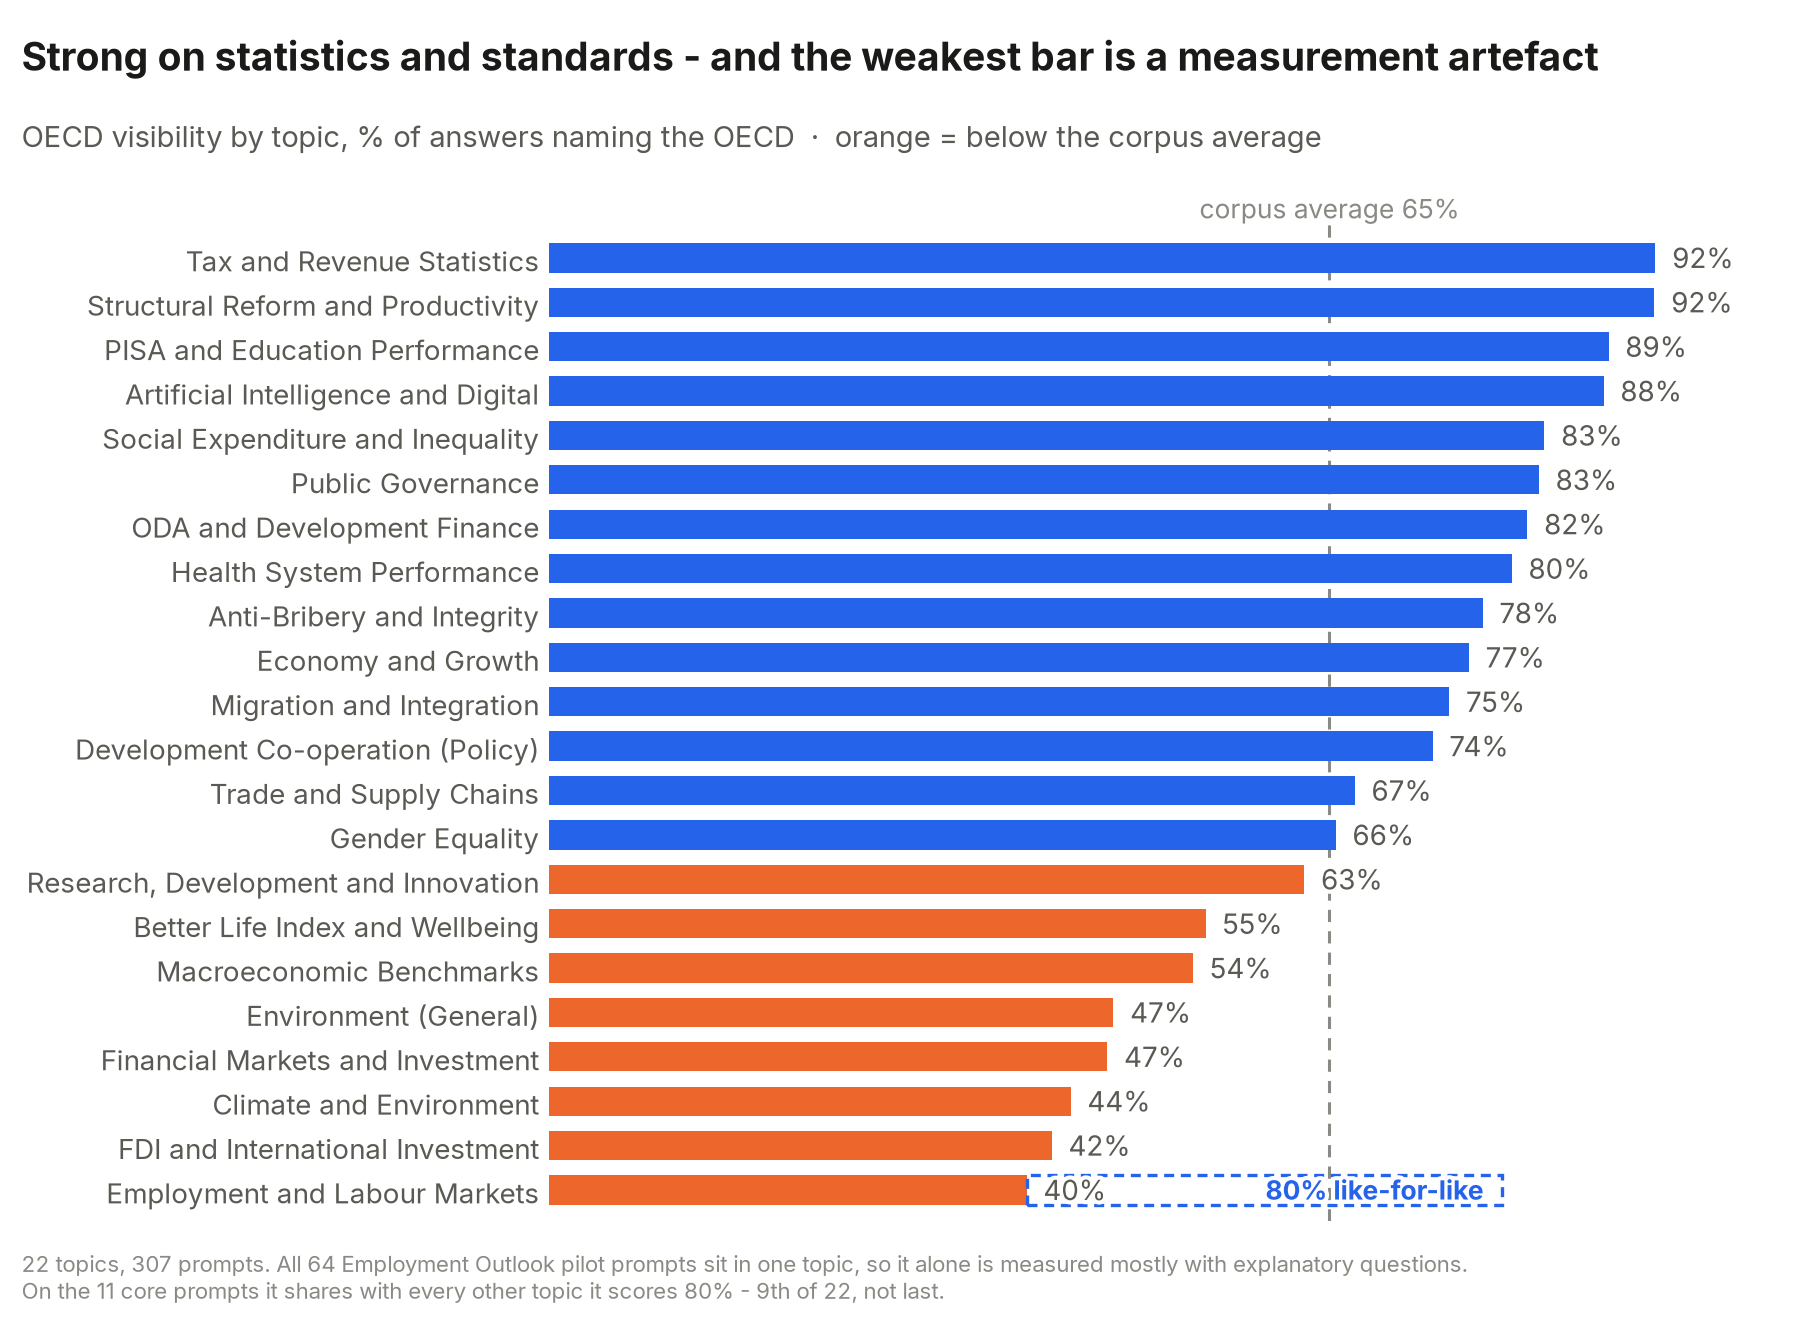

*Visibility by topic. The Employment bar is drawn twice - pooled, and on core prompts only (the ghost bar) - so the panel artefact from Layer 4 stays visible.*

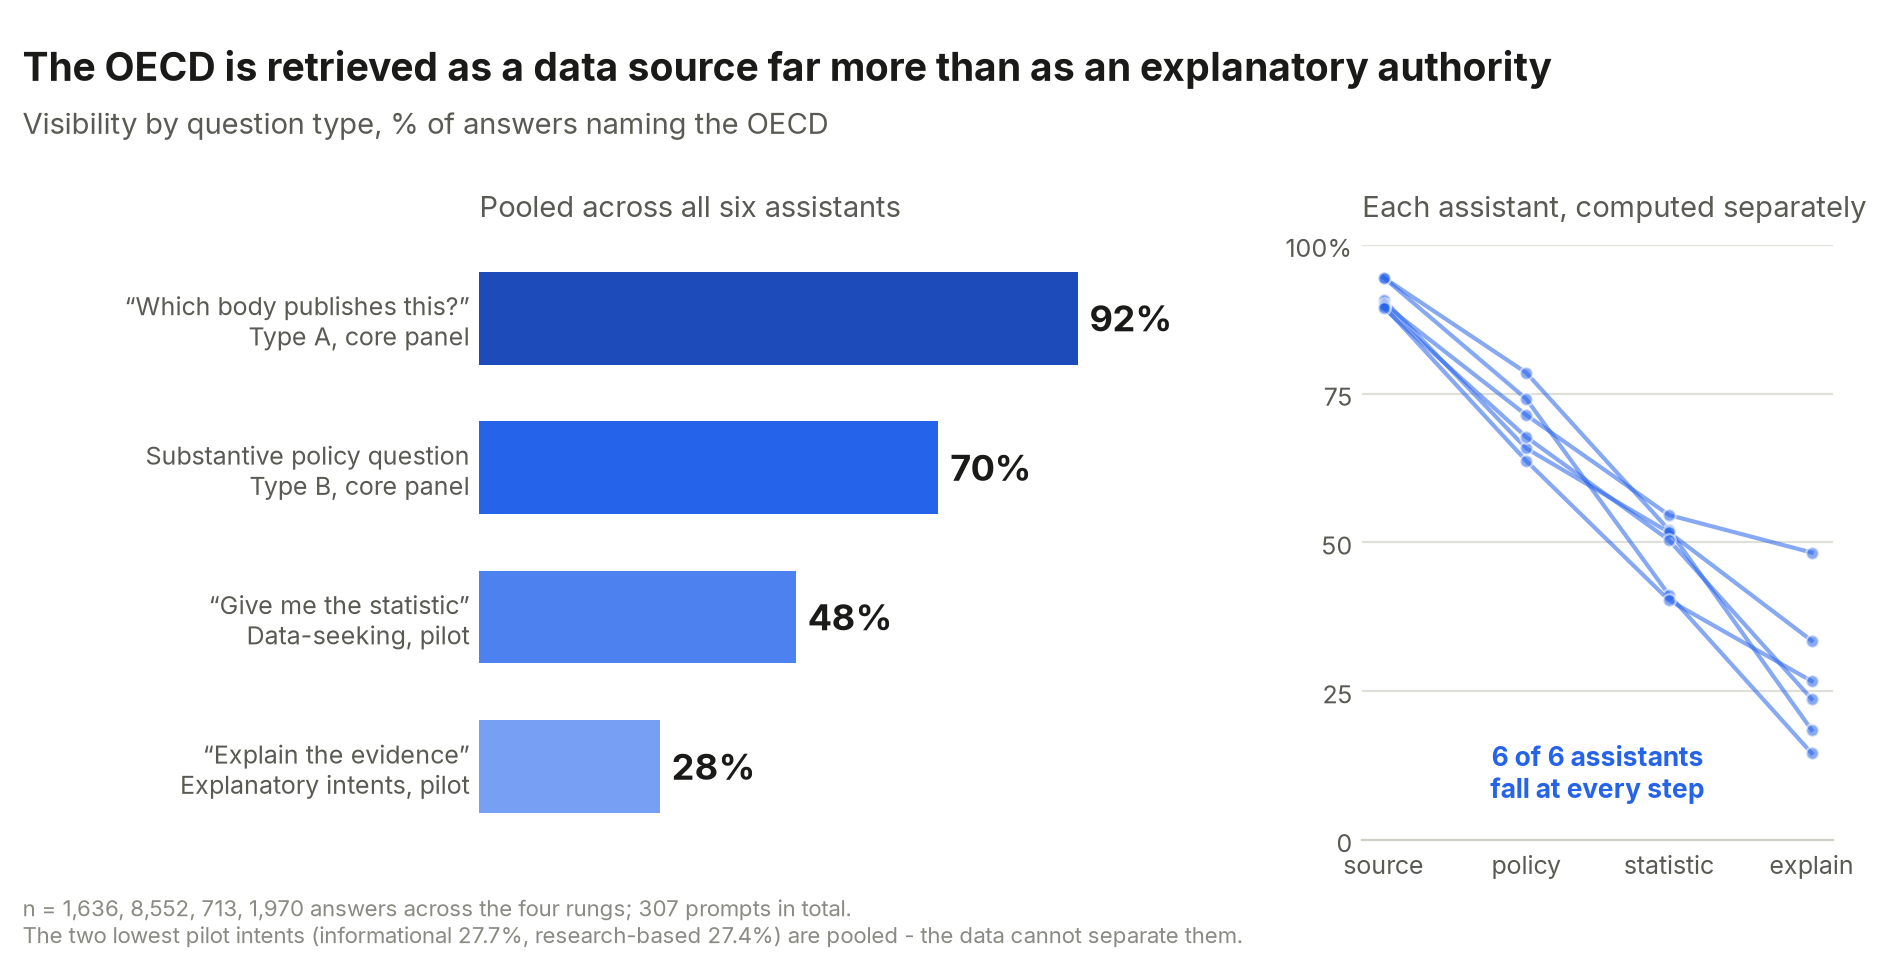

*The question-type ladder, recomputed inside each assistant separately.*

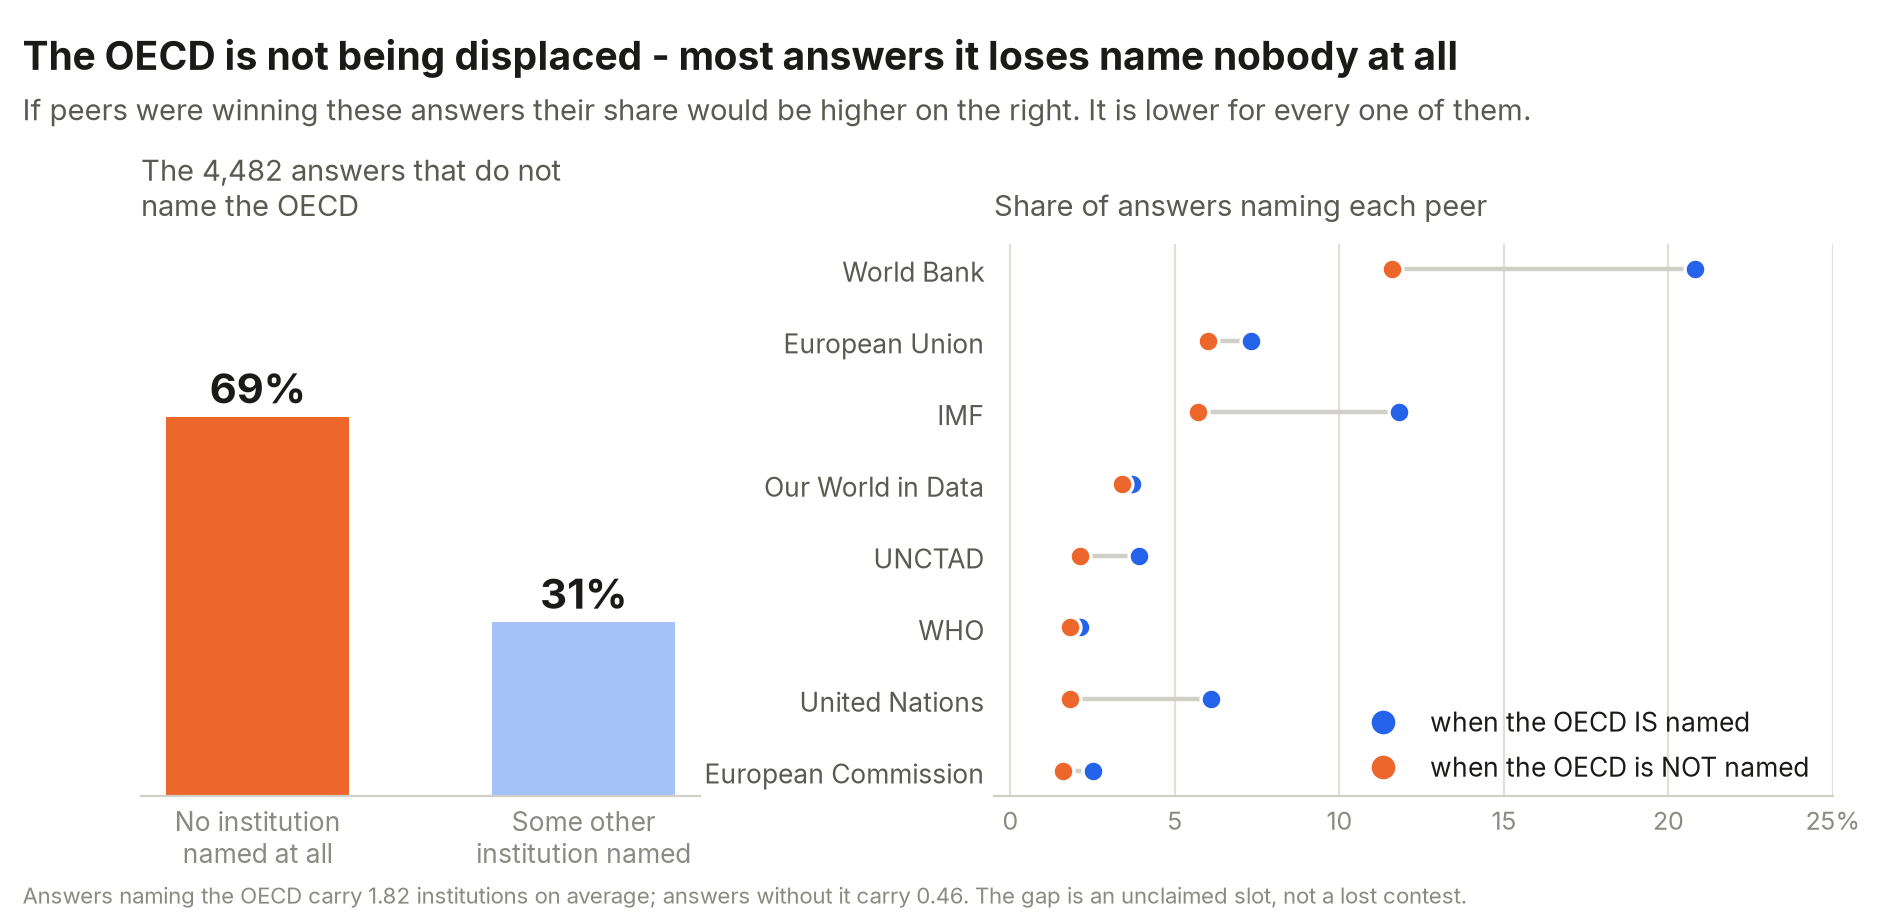

*Peer share of voice with the OECD present vs absent. Every peer is *lower* where the OECD is absent: the gap is a vacancy, not a lost contest.*

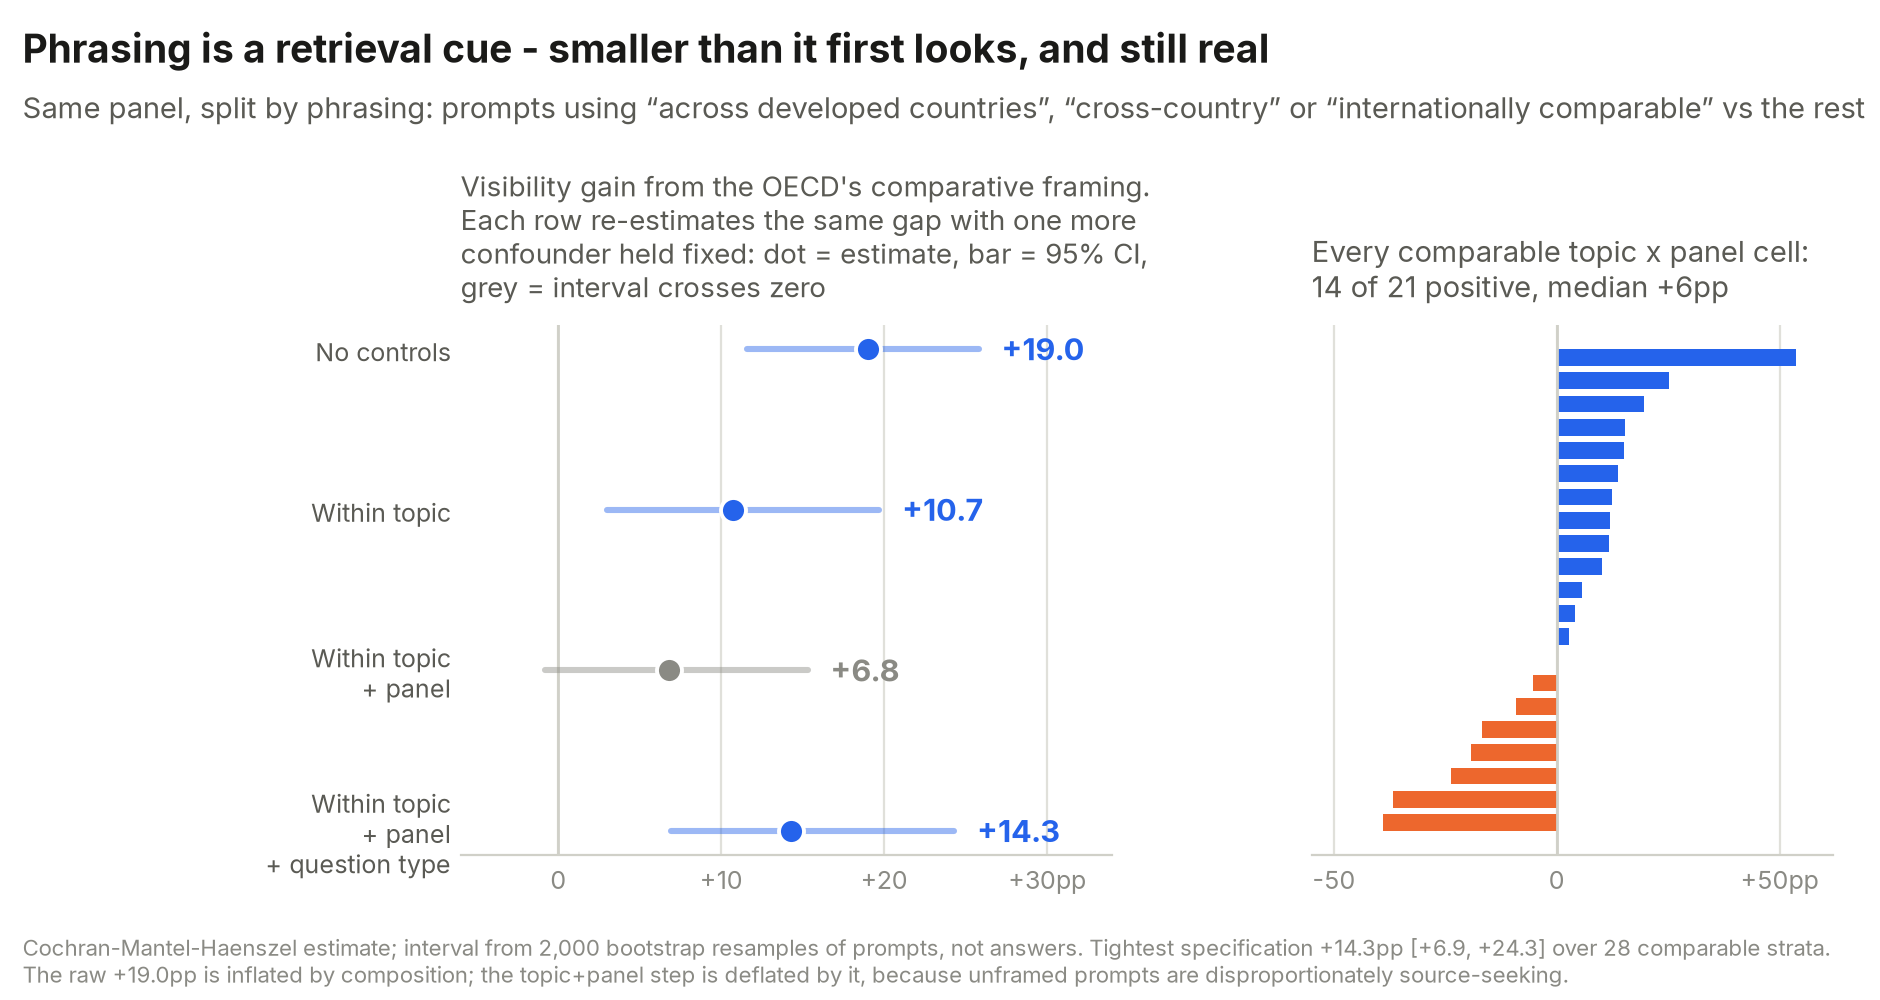

*The register effect as a specification curve. Left: each row re-estimates the same framed-vs-unframed visibility gap while holding one more confounder fixed - top row nothing, bottom row topic, panel and question type together. The dot is the estimated gain, the bar its 95% interval, and grey marks the one step where the interval crosses zero. Reading down the rows shows how much of the raw +19pp was composition and how much survives: +14.3pp. Right: the framed-vs-unframed gap in every comparable topic x panel cell, the raw material behind the pooled estimate - positive in most cells, not unanimously, which is what a real but modest effect looks like.*

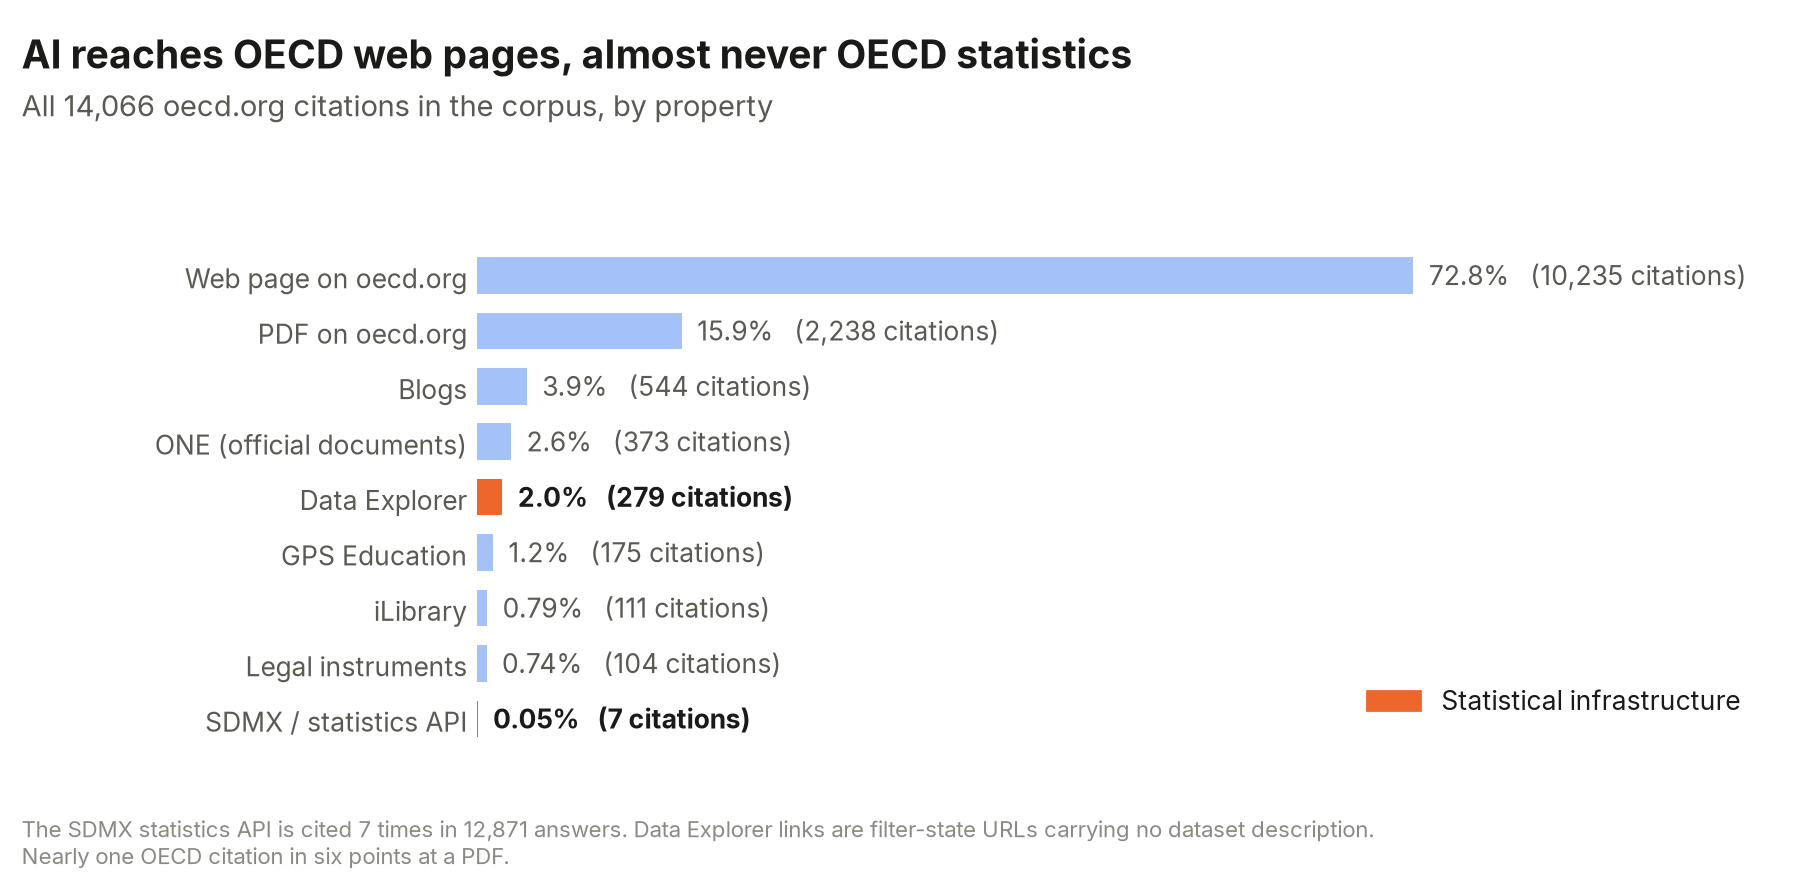

*Where 14,066 oecd.org citations land: web pages and PDFs, essentially never the statistics.*

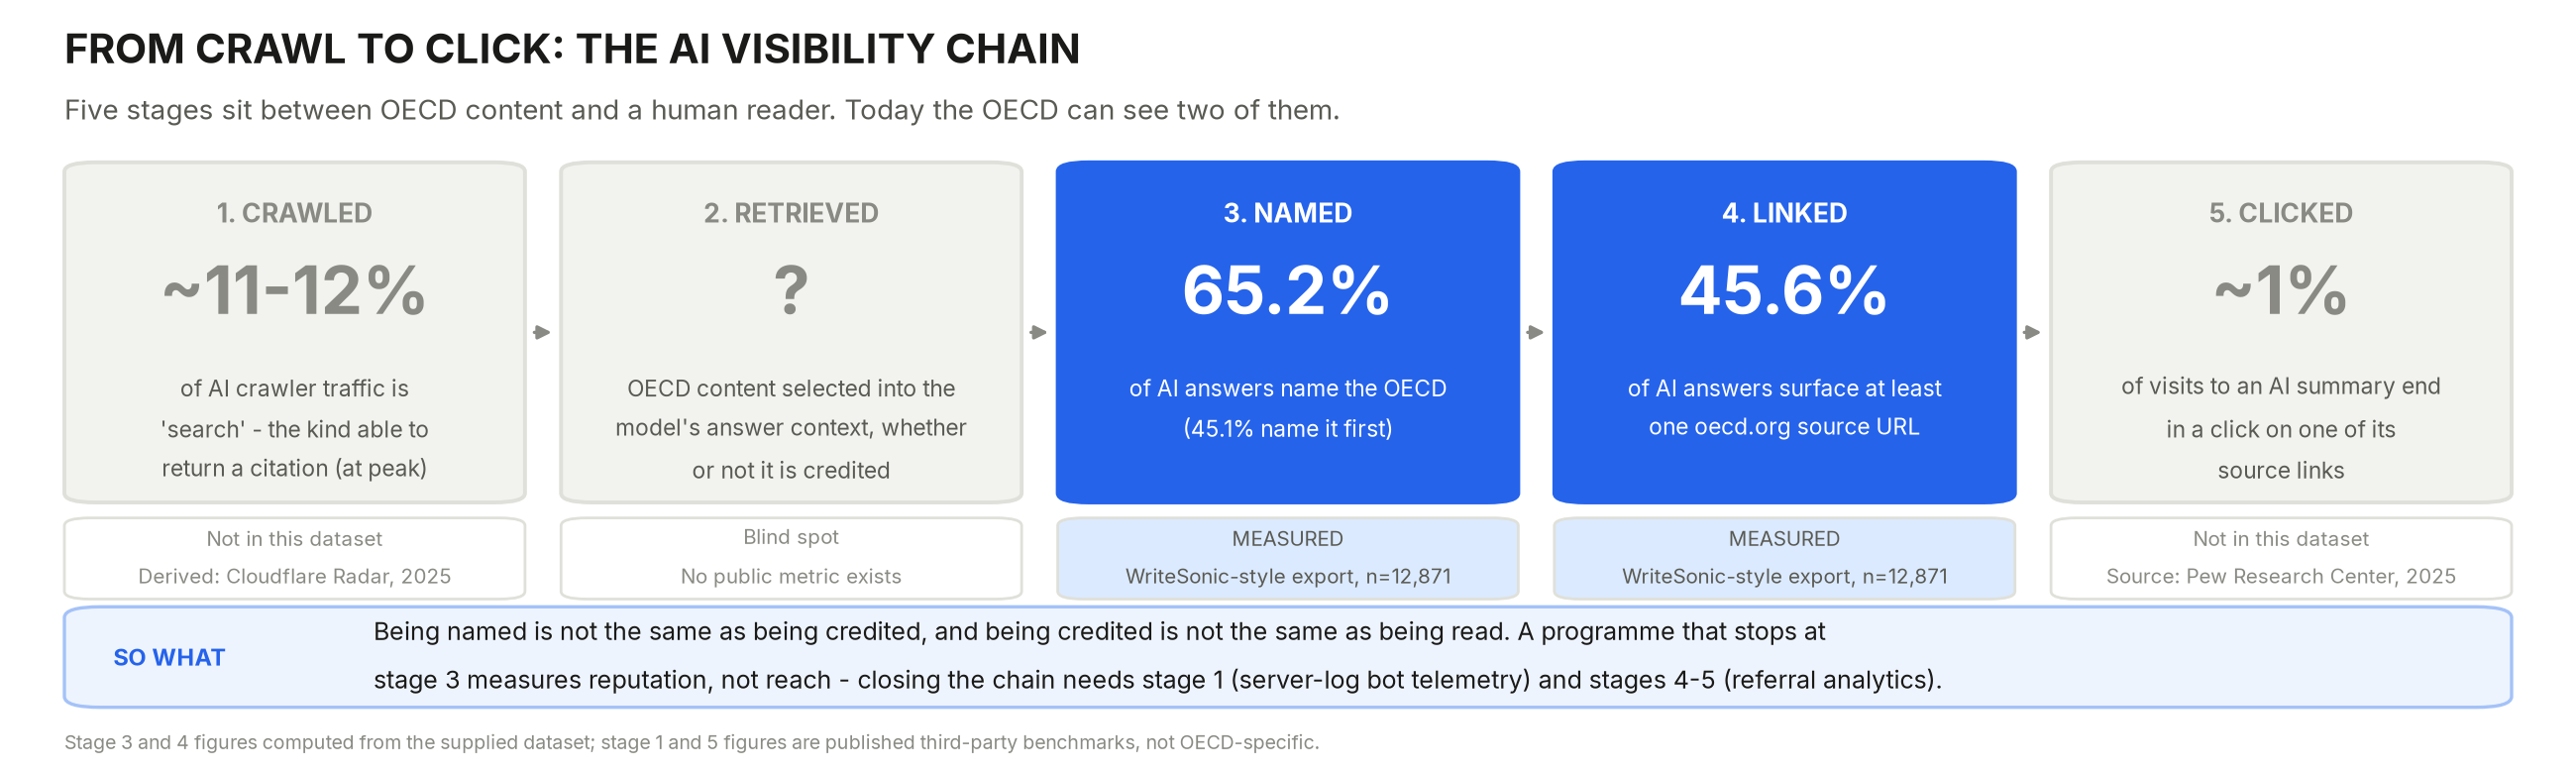

*The crawl-to-click chain: the two stages this dataset measures and the three it cannot see.*

In [77]:
from IPython.display import Image, Markdown, display

EXHIBITS = [
    ("fig3_topic",
     "Visibility by topic. The Employment bar is drawn twice - pooled, and on core "
     "prompts only (the ghost bar) - so the panel artefact from Layer 4 stays visible."),
    ("fig4_question_gradient",
     "The question-type ladder, recomputed inside each assistant separately."),
    ("fig10_displacement",
     "Peer share of voice with the OECD present vs absent. Every peer is *lower* "
     "where the OECD is absent: the gap is a vacancy, not a lost contest."),
    ("fig8_register_effect",
     "The register effect as a specification curve. Left: each row re-estimates the "
     "same framed-vs-unframed visibility gap while holding one more confounder fixed - "
     "top row nothing, bottom row topic, panel and question type together. The dot is "
     "the estimated gain, the bar its 95% interval, and grey marks the one step where "
     "the interval crosses zero. Reading down the rows shows how much of the raw +19pp "
     "was composition and how much survives: +14.3pp. Right: the framed-vs-unframed "
     "gap in every comparable topic x panel cell, the raw material behind the pooled "
     "estimate - positive in most cells, not unanimously, which is what a real but "
     "modest effect looks like."),
    ("fig9_retrievability",
     "Where 14,066 oecd.org citations land: web pages and PDFs, essentially never "
     "the statistics."),
    ("fig7_ai_answer_funnel",
     "The crawl-to-click chain: the two stages this dataset measures and the three "
     "it cannot see."),
]
for name, caption in EXHIBITS:
    display(Image(filename=f"outputs/figures/{name}.png", width=900))
    display(Markdown(f"*{caption}*"))

---
## 9. What this means

1. **The OECD's AI visibility problem is not reach, and it is not a topic.** 65%
   overall and a 3.7x lead over the World Bank is a strong starting position. The
   gap is between being retrieved as *a source of numbers* (92%) and as *a source
   of explanation* (28%) - a ladder that falls at every step on all six
   assistants independently. It is strong enough to counterfeit a subject-matter
   weakness: employment reads as the OECD's worst topic at 40% and is 80% once
   the question mix is held constant. The answer text confirms the role from
   inside: only 5% of the answers that name the OECD give it a voice - the rest
   quote its data or use "the OECD average" as a yardstick.

2. **There is no competitor to beat.** In the 4,482 answers without the OECD,
   69% name no institution at all, and every peer appears *less* often than when
   the OECD is present. The ladder decomposition shows the same fact from above:
   down the four rungs the share of answers naming *any* institution collapses
   from 98% to 38%, while the OECD's capture of the slot, when one exists, holds
   at 73-93%. The only genuinely contested relationships in the file
   are with the specialist agencies on their own turf - the IMF on
   macro-financial questions and, on a thinner base, the ILO on labour - and
   even there the OECD still takes the first slot roughly six times in ten.
   Everywhere else the gap is unmet supply, not lost share - which is why the
   first recommendation is to publish into it rather than to position against
   anyone.

3. **Phrasing is a real but modest lever, and the panel is written in the OECD's
   own voice.** The comparative register is worth +14.3pp [+6.9, +24.3] under
   full controls, down from an uncontrolled +19pp and a badly confounded +42pp on
   employment. The panel contains no plainly-worded substantive question, so
   65.2% is an upper bound on visibility to a general audience.

4. **Attribution leaks at the last step - and the leak is absence, not
   burial.** Between a quarter and a third of mentions carry no link home,
   though a link that does surface leads the citation list (top three 68% of
   the time). And 7 of 14,066 OECD citations reach the statistics API. The
   OECD earns the authority and loses both the referral and the data.

5. **The measurement itself is noisy.** 38% of prompt-platform pairs flip within
   a week, assistants differ by 48pp on the average prompt, and one platform's
   link rate halved overnight mid-window. The corpus rate carries a
   prompt-clustered interval of ±3.7pp even at the full design. Any KPI built on
   this must be a band, not a point - and a per-platform band at that.

**What changed by being careful.** Two of the fourteen data-quality checks graded
BLOCKING, and both changed a conclusion that had already been written down: the
citation-capture check reversed the platform ranking, and the panel/topic
confound turned "the OECD is weak on employment" into "the topic table is ranking
question types". A third correction - the +42pp register effect - came from
applying the same discipline to a number that flattered the analysis, and a
fourth - precision intervals originally computed on 12,871 answers rather than
307 prompts - widened every stated interval about fivefold. None of these were
visible in the vendor's fields; they came from splitting the two prompt panels
apart, refusing to average them, and refusing to count repeated measures as
independent evidence.

The recommendations that follow - publishing answer-shaped explanatory content in
plain register on the weak question types, giving the statistics a describable
retrievable surface, and instrumenting the full crawl-to-click chain with a
governed, banded metric - are set out in the executive briefing.